In [47]:
import pandas as pd

In [48]:
df = pd.read_csv("credit_risk_clean.csv")

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372136 entries, 0 to 372135
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            372136 non-null  float64
 1   term                 372136 non-null  object 
 2   int_rate             372136 non-null  float64
 3   installment          372136 non-null  float64
 4   grade                372136 non-null  object 
 5   sub_grade            372136 non-null  object 
 6   emp_length           372136 non-null  object 
 7   home_ownership       372136 non-null  object 
 8   annual_inc           372136 non-null  float64
 9   verification_status  372136 non-null  object 
 10  dti                  372136 non-null  float64
 11  fico_range_low       372136 non-null  float64
 12  fico_range_high      372136 non-null  float64
 13  inq_last_6mths       372136 non-null  float64
 14  open_acc             372136 non-null  float64
 15  pub_rec          

In [50]:
df.isna().count()

loan_amnt              372136
term                   372136
int_rate               372136
installment            372136
grade                  372136
sub_grade              372136
emp_length             372136
home_ownership         372136
annual_inc             372136
verification_status    372136
dti                    372136
fico_range_low         372136
fico_range_high        372136
inq_last_6mths         372136
open_acc               372136
pub_rec                372136
revol_bal              372136
revol_util             372136
total_acc              372136
loan_status            372136
target                 372136
income_bucket          372136
dti_bucket             372136
dtype: int64

In [51]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,loan_status,target,income_bucket,dti_bucket
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,1.0,7.0,0.0,2765.0,29.7,13.0,Fully Paid,0,"(43500.0, 58400.0]","(-0.001, 10.95]"
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,4.0,22.0,0.0,21470.0,19.2,38.0,Fully Paid,0,"(58400.0, 75000.0]","(15.91, 20.68]"
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,0.0,6.0,0.0,7869.0,56.2,18.0,Fully Paid,0,"(58400.0, 75000.0]","(-0.001, 10.95]"
3,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,3.0,12.0,0.0,21929.0,64.5,35.0,Fully Paid,0,"(100000.0, 9500000.0]","(20.68, 26.63]"
4,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,0.0,5.0,0.0,8822.0,68.4,6.0,Fully Paid,0,"(32.999, 43500.0]","(-0.001, 10.95]"


In [ ]:
                                                 Encoding categorical variables

In [52]:
df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

In [53]:
df['term'].head()

0    36
1    36
2    60
3    60
4    36
Name: term, dtype: int64

In [54]:
df['emp_length'] = df['emp_length'].str.replace(' years', '')
df['emp_length'] = df['emp_length'].str.replace(' year', '')
df['emp_length'] = df['emp_length'].str.replace('+', '')
df['emp_length'] = df['emp_length'].str.replace('< ', '')
df['emp_length'] = df['emp_length'].astype(float)

In [55]:
df['emp_length'].head(30)

0     10.0
1     10.0
2     10.0
3      3.0
4      4.0
5     10.0
6     10.0
7      6.0
8     10.0
9      3.0
10     7.0
11    10.0
12     8.0
13    10.0
14    10.0
15     8.0
16    10.0
17    10.0
18     2.0
19     2.0
20    10.0
21     5.0
22     9.0
23     1.0
24     1.0
25    10.0
26    10.0
27     4.0
28     1.0
29     9.0
Name: emp_length, dtype: float64

In [57]:
df['emp_length'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 372136 entries, 0 to 372135
Series name: emp_length
Non-Null Count   Dtype  
--------------   -----  
372136 non-null  float64
dtypes: float64(1)
memory usage: 2.8 MB


In [58]:
df['emp_length'].unique()

array([10.,  3.,  4.,  6.,  7.,  8.,  2.,  5.,  9.,  1.])

In [59]:
df['emp_length'].head(10)

0    10.0
1    10.0
2    10.0
3     3.0
4     4.0
5    10.0
6    10.0
7     6.0
8    10.0
9     3.0
Name: emp_length, dtype: float64

In [60]:
grade_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}
df['grade'] = df['grade'].map(grade_map)

In [61]:
df['grade'].unique()

array([3, 2, 6, 1, 5, 4, 7])

In [ ]:
Here -> GRADE → ordinal risk ladder

A safest → G riskiest.

In [62]:
df.drop('sub_grade', axis=1, inplace=True) # here droping sub_grade because grade is already converted and using any one is enough

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372136 entries, 0 to 372135
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            372136 non-null  float64
 1   term                 372136 non-null  int64  
 2   int_rate             372136 non-null  float64
 3   installment          372136 non-null  float64
 4   grade                372136 non-null  int64  
 5   emp_length           372136 non-null  float64
 6   home_ownership       372136 non-null  object 
 7   annual_inc           372136 non-null  float64
 8   verification_status  372136 non-null  object 
 9   dti                  372136 non-null  float64
 10  fico_range_low       372136 non-null  float64
 11  fico_range_high      372136 non-null  float64
 12  inq_last_6mths       372136 non-null  float64
 13  open_acc             372136 non-null  float64
 14  pub_rec              372136 non-null  float64
 15  revol_bal        

In [64]:
print(df['home_ownership'].value_counts())
print(df['home_ownership'].value_counts(normalize=True) * 100)

home_ownership
MORTGAGE    181424
RENT        151942
OWN          38768
ANY              2
Name: count, dtype: int64
home_ownership
MORTGAGE    48.752069
RENT        40.829697
OWN         10.417697
ANY          0.000537
Name: proportion, dtype: float64


In [65]:
#Replace rare category
df['home_ownership'] = df['home_ownership'].replace('ANY', 'OTHER')

In [66]:
home_dummies = pd.get_dummies(df['home_ownership'], prefix='home', drop_first=True)

df = pd.concat([df, home_dummies], axis=1)

df.drop('home_ownership', axis=1, inplace=True)

In [67]:
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,dti,fico_range_low,...,revol_bal,revol_util,total_acc,loan_status,target,income_bucket,dti_bucket,home_OTHER,home_OWN,home_RENT
0,3600.0,36,13.99,123.03,3,10.0,55000.0,Not Verified,5.91,675.0,...,2765.0,29.7,13.0,Fully Paid,0,"(43500.0, 58400.0]","(-0.001, 10.95]",False,False,False
1,24700.0,36,11.99,820.28,3,10.0,65000.0,Not Verified,16.06,715.0,...,21470.0,19.2,38.0,Fully Paid,0,"(58400.0, 75000.0]","(15.91, 20.68]",False,False,False
2,20000.0,60,10.78,432.66,2,10.0,63000.0,Not Verified,10.78,695.0,...,7869.0,56.2,18.0,Fully Paid,0,"(58400.0, 75000.0]","(-0.001, 10.95]",False,False,False
3,10400.0,60,22.45,289.91,6,3.0,104433.0,Source Verified,25.37,695.0,...,21929.0,64.5,35.0,Fully Paid,0,"(100000.0, 9500000.0]","(20.68, 26.63]",False,False,False
4,11950.0,36,13.44,405.18,3,4.0,34000.0,Source Verified,10.20,690.0,...,8822.0,68.4,6.0,Fully Paid,0,"(32.999, 43500.0]","(-0.001, 10.95]",False,False,True


In [68]:
list(df.columns)

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'emp_length',
 'annual_inc',
 'verification_status',
 'dti',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'loan_status',
 'target',
 'income_bucket',
 'dti_bucket',
 'home_OTHER',
 'home_OWN',
 'home_RENT']

In [69]:
df[(df['home_OTHER']==0) & 
   (df['home_OWN']==0) & 
   (df['home_RENT']==0)].head()

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,dti,fico_range_low,...,revol_bal,revol_util,total_acc,loan_status,target,income_bucket,dti_bucket,home_OTHER,home_OWN,home_RENT
0,3600.0,36,13.99,123.03,3,10.0,55000.0,Not Verified,5.91,675.0,...,2765.0,29.7,13.0,Fully Paid,0,"(43500.0, 58400.0]","(-0.001, 10.95]",False,False,False
1,24700.0,36,11.99,820.28,3,10.0,65000.0,Not Verified,16.06,715.0,...,21470.0,19.2,38.0,Fully Paid,0,"(58400.0, 75000.0]","(15.91, 20.68]",False,False,False
2,20000.0,60,10.78,432.66,2,10.0,63000.0,Not Verified,10.78,695.0,...,7869.0,56.2,18.0,Fully Paid,0,"(58400.0, 75000.0]","(-0.001, 10.95]",False,False,False
3,10400.0,60,22.45,289.91,6,3.0,104433.0,Source Verified,25.37,695.0,...,21929.0,64.5,35.0,Fully Paid,0,"(100000.0, 9500000.0]","(20.68, 26.63]",False,False,False
5,20000.0,36,9.17,637.58,2,10.0,180000.0,Not Verified,14.67,680.0,...,87329.0,84.5,27.0,Fully Paid,0,"(100000.0, 9500000.0]","(10.95, 15.91]",False,False,False


In [70]:
bool_cols = ['home_OTHER', 'home_OWN', 'home_RENT']

df[bool_cols] = df[bool_cols].astype(int)

In [71]:
df[bool_cols].head()

,home_OTHER,home_OWN,home_RENT
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,1


In [72]:
df = pd.get_dummies(df, columns=['verification_status'], drop_first=True)

In [73]:
list(df.columns)

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'emp_length',
 'annual_inc',
 'dti',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'loan_status',
 'target',
 'income_bucket',
 'dti_bucket',
 'home_OTHER',
 'home_OWN',
 'home_RENT',
 'verification_status_Source Verified',
 'verification_status_Verified']

In [74]:
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,dti,fico_range_low,fico_range_high,...,total_acc,loan_status,target,income_bucket,dti_bucket,home_OTHER,home_OWN,home_RENT,verification_status_Source Verified,verification_status_Verified
0,3600.0,36,13.99,123.03,3,10.0,55000.0,5.91,675.0,679.0,...,13.0,Fully Paid,0,"(43500.0, 58400.0]","(-0.001, 10.95]",0,0,0,False,False
1,24700.0,36,11.99,820.28,3,10.0,65000.0,16.06,715.0,719.0,...,38.0,Fully Paid,0,"(58400.0, 75000.0]","(15.91, 20.68]",0,0,0,False,False
2,20000.0,60,10.78,432.66,2,10.0,63000.0,10.78,695.0,699.0,...,18.0,Fully Paid,0,"(58400.0, 75000.0]","(-0.001, 10.95]",0,0,0,False,False
3,10400.0,60,22.45,289.91,6,3.0,104433.0,25.37,695.0,699.0,...,35.0,Fully Paid,0,"(100000.0, 9500000.0]","(20.68, 26.63]",0,0,0,True,False
4,11950.0,36,13.44,405.18,3,4.0,34000.0,10.20,690.0,694.0,...,6.0,Fully Paid,0,"(32.999, 43500.0]","(-0.001, 10.95]",0,0,1,True,False


In [75]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [76]:
df["verification_status_Source Verified"].head()

0    0
1    0
2    0
3    1
4    1
Name: verification_status_Source Verified, dtype: int64

In [77]:
df["verification_status_Verified"].head()

0    0
1    0
2    0
3    0
4    0
Name: verification_status_Verified, dtype: int64

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372136 entries, 0 to 372135
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            372136 non-null  float64
 1   term                                 372136 non-null  int64  
 2   int_rate                             372136 non-null  float64
 3   installment                          372136 non-null  float64
 4   grade                                372136 non-null  int64  
 5   emp_length                           372136 non-null  float64
 6   annual_inc                           372136 non-null  float64
 7   dti                                  372136 non-null  float64
 8   fico_range_low                       372136 non-null  float64
 9   fico_range_high                      372136 non-null  float64
 10  inq_last_6mths                       372136 non-null  float64
 11  open_acc     

In [79]:
df = df.drop(columns=['loan_status', 'income_bucket', 'dti_bucket'])

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372136 entries, 0 to 372135
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            372136 non-null  float64
 1   term                                 372136 non-null  int64  
 2   int_rate                             372136 non-null  float64
 3   installment                          372136 non-null  float64
 4   grade                                372136 non-null  int64  
 5   emp_length                           372136 non-null  float64
 6   annual_inc                           372136 non-null  float64
 7   dti                                  372136 non-null  float64
 8   fico_range_low                       372136 non-null  float64
 9   fico_range_high                      372136 non-null  float64
 10  inq_last_6mths                       372136 non-null  float64
 11  open_acc     

In [ ]:
                                                  Train/Test Split

In [81]:
X = df.drop('target', axis=1)
y = df['target']

In [82]:
print(X.shape)
print(y.shape)

(372136, 21)
(372136,)


In [ ]:
HERE , DATA IS IMBALANCED

Earlier you saw:

~80% → Non-default

~20% → Default

If we split randomly, sometimes test set may get wrong proportions.

So we use STRATIFIED SPLIT.

This keeps same ratio in train & test.

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80 train, 20 test
    random_state=42,
    stratify=y              # keeps default ratio same
)

In [85]:
print("Train target ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest target ratio:")
print(y_test.value_counts(normalize=True))

Train target ratio:
target
0    0.792595
1    0.207405
Name: proportion, dtype: float64

Test target ratio:
target
0    0.792591
1    0.207409
Name: proportion, dtype: float64


In [ ]:
                                                  Train Model - LOGISTIC REGRESSION 

In [86]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
Logistic Regression struggles to optimise when numbers vary this much. So We scale train dataand use the SAME scaling for test data.
Never fit scaler on test set.

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [89]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [90]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[57166  1825]
 [13097  2340]]


In [91]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.97      0.88     58991
           1       0.56      0.15      0.24     15437

    accuracy                           0.80     74428
   macro avg       0.69      0.56      0.56     74428
weighted avg       0.76      0.80      0.75     74428



In [92]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.7350391489455561


In [ ]:
Training & Evaluation Summary

A logistic regression model was developed to predict the probability of loan default using borrower financial and credit attributes. 
The dataset was preprocessed through missing value treatment, categorical encoding, feature scaling, 
and stratified train–test splitting to preserve class imbalance.

Model performance was evaluated using confusion matrix, precision, recall, F1-score, and ROC-AUC. 
The model achieved an AUC of 0.73, demonstrating strong discriminatory power between good and bad borrowers.
While precision for defaulters was moderate, recall indicated that further threshold tuning or advanced models could improve detection of 
high-risk applicants.

In [ ]:
                                                              Random Forest Classifier

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))

[[57660  1331]
 [13727  1710]]
              precision    recall  f1-score   support

           0       0.81      0.98      0.88     58991
           1       0.56      0.11      0.19     15437

    accuracy                           0.80     74428
   macro avg       0.69      0.54      0.53     74428
weighted avg       0.76      0.80      0.74     74428

AUC: 0.728928040663334


In [94]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    print(f"\nThreshold: {t}")
    y_pred_new = (y_prob_rf > t).astype(int)
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))


Threshold: 0.5
[[57660  1331]
 [13727  1710]]
              precision    recall  f1-score   support

           0       0.81      0.98      0.88     58991
           1       0.56      0.11      0.19     15437

    accuracy                           0.80     74428
   macro avg       0.69      0.54      0.53     74428
weighted avg       0.76      0.80      0.74     74428


Threshold: 0.4
[[55140  3851]
 [11579  3858]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.88     58991
           1       0.50      0.25      0.33     15437

    accuracy                           0.79     74428
   macro avg       0.66      0.59      0.61     74428
weighted avg       0.76      0.79      0.76     74428


Threshold: 0.3
[[49885  9106]
 [ 8624  6813]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85     58991
           1       0.43      0.44      0.43     15437

    accuracy                           0.

In [ ]:
                                                   Logistic Regression Threshhold Tuning

  LOGISTIC REGRESSION — THRESHOLD TUNING RESULTS
 Threshold  Accuracy  Precision_0  Recall_0   F1_0  Precision_1  Recall_1   F1_1   AUC
      0.10    0.4185       0.9386    0.2850 0.4372       0.2537    0.9287 0.3985 0.735
      0.15    0.5744       0.9084    0.5149 0.6573       0.3019    0.8015 0.4386 0.735
      0.20    0.6764       0.8853    0.6797 0.7690       0.3515    0.6635 0.4596 0.735
      0.25    0.7372       0.8673    0.7891 0.8264       0.4007    0.5387 0.4595 0.735
      0.30    0.7682       0.8525    0.8556 0.8540       0.4403    0.4342 0.4372 0.735
      0.35    0.7844       0.8406    0.8982 0.8685       0.4732    0.3493 0.4019 0.735
      0.40    0.7941       0.8310    0.9292 0.8773       0.5066    0.2777 0.3587 0.735
      0.45    0.7985       0.8217    0.9524 0.8823       0.5363    0.2103 0.3022 0.735
      0.50    0.7995       0.8136    0.9691 0.8846       0.5618    0.1516 0.2388 0.735
      0.55    0.7994       0.8069    0.9817 0.8858       0.5947    0.1025 0.1748 

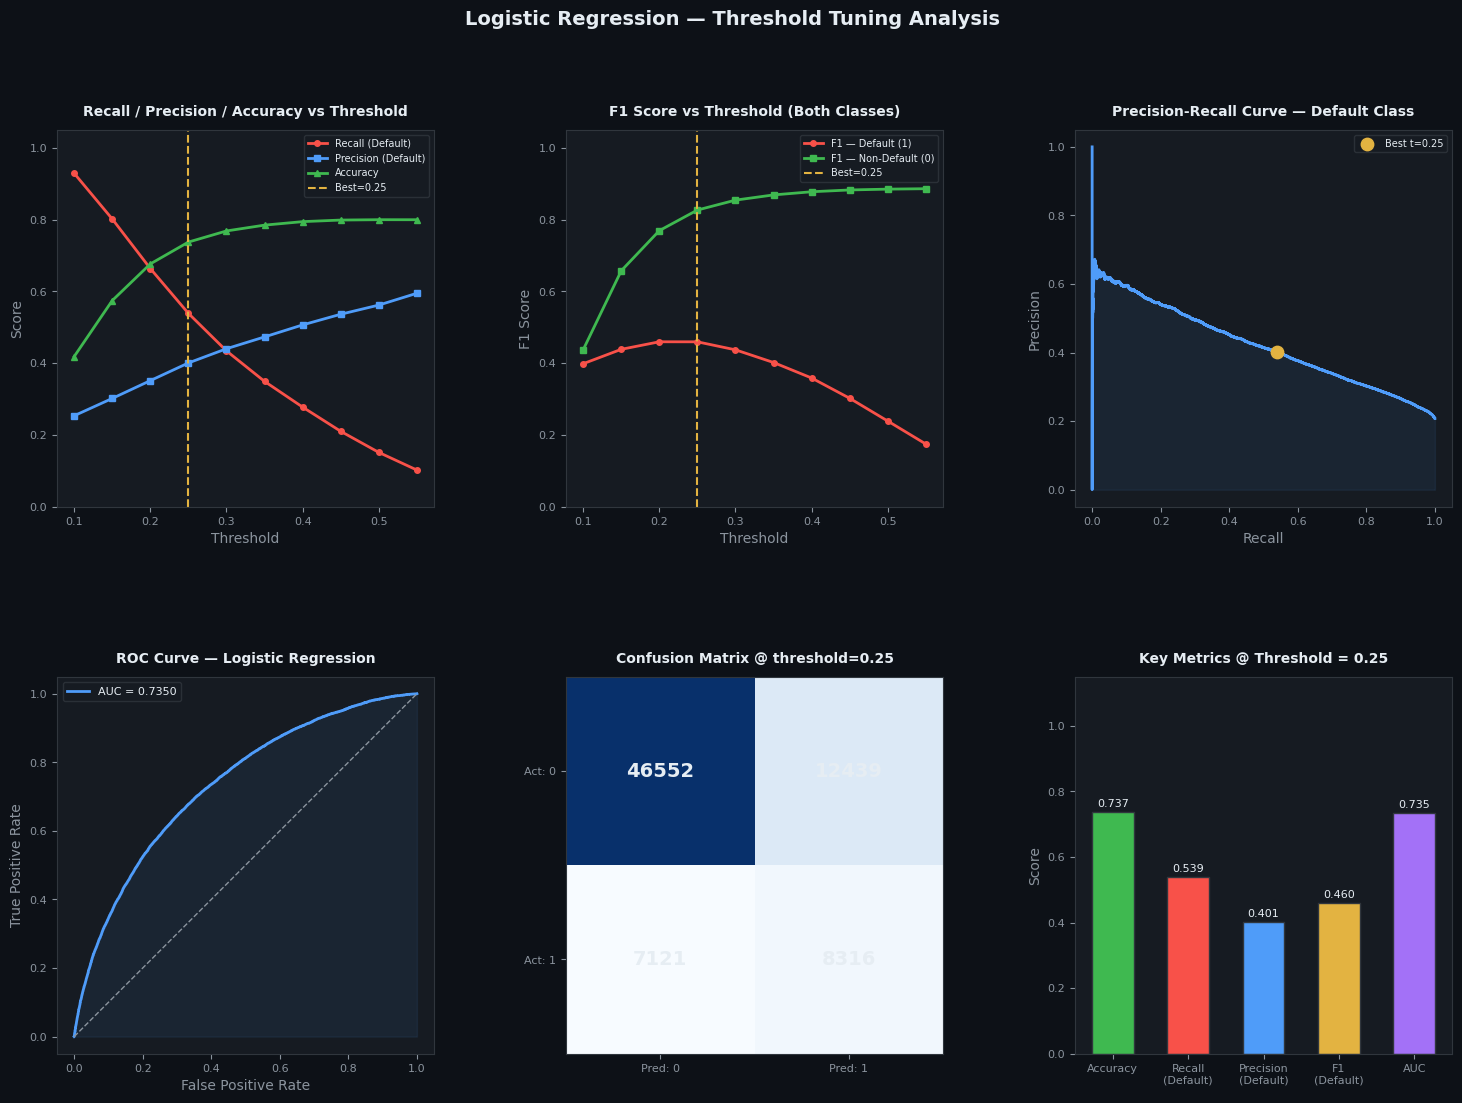


✅ Plot saved as 'lr_threshold_tuning.png'
────────────────────────────────────────────────────────────
  NEXT → Run Cell 2 for Random Forest Threshold Tuning
────────────────────────────────────────────────────────────


In [95]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, classification_report, f1_score,
    precision_score, recall_score
)

# ── 1. Build full threshold comparison table ──────────────────
thresholds_to_test = np.arange(0.1, 0.6, 0.05).round(2)

results = []
for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)
    results.append({
        'Threshold'      : t,
        'Accuracy'       : round((y_pred_t == y_test).mean(), 4),
        'Precision_0'    : round(precision_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Recall_0'       : round(recall_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'F1_0'           : round(f1_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Precision_1'    : round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'Recall_1'       : round(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'F1_1'           : round(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'AUC'            : round(roc_auc_score(y_test, y_prob), 4),  # AUC stays fixed
    })

import pandas as pd
results_df = pd.DataFrame(results)

print("=" * 90)
print("  LOGISTIC REGRESSION — THRESHOLD TUNING RESULTS")
print("=" * 90)
print(results_df.to_string(index=False))
print()

# ── 2. Find recommended threshold ────────────────────────────
# Goal: Recall_1 >= 0.50 AND Precision_1 >= 0.35 AND Accuracy >= 0.70
# (banking context: catching defaulters matters more than precision)
candidates = results_df[
    (results_df['Recall_1'] >= 0.45) &
    (results_df['Precision_1'] >= 0.30) &
    (results_df['Accuracy'] >= 0.68)
]

if not candidates.empty:
    # Pick best F1 for class 1 among candidates
    best_row = candidates.loc[candidates['F1_1'].idxmax()]
    best_threshold = best_row['Threshold']
    print(f"✅ RECOMMENDED THRESHOLD : {best_threshold}")
    print(f"   Accuracy      : {best_row['Accuracy']}")
    print(f"   Recall  (1)   : {best_row['Recall_1']}   ← Defaulters caught")
    print(f"   Precision (1) : {best_row['Precision_1']}")
    print(f"   F1 Score (1)  : {best_row['F1_1']}")
    print(f"   AUC           : {best_row['AUC']}")
else:
    best_threshold = 0.3
    print(f"ℹ️  No threshold perfectly met all criteria. Using 0.3 as best trade-off.")

# ── 3. Detailed report at recommended threshold ───────────────
print()
print(f"{'='*60}")
print(f"  DETAILED REPORT AT THRESHOLD = {best_threshold}")
print(f"{'='*60}")
y_pred_best = (y_prob >= best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_best))
print()
print(classification_report(y_test, y_pred_best, target_names=['Non-Default','Default']))

# ── 4. Plots ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK  = '#0d1117'
SURF  = '#161b22'
BLUE  = '#4f9cf9'
GREEN = '#3fb950'
RED   = '#f85149'
AMBER = '#e3b341'
GRAY  = '#8b949e'
WHITE = '#e6edf3'

def style_ax(ax, title):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# — Plot 1: Recall & Precision vs Threshold —
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(results_df['Threshold'], results_df['Recall_1'],
         color=RED, linewidth=2, marker='o', markersize=4, label='Recall (Default)')
ax1.plot(results_df['Threshold'], results_df['Precision_1'],
         color=BLUE, linewidth=2, marker='s', markersize=4, label='Precision (Default)')
ax1.plot(results_df['Threshold'], results_df['Accuracy'],
         color=GREEN, linewidth=2, marker='^', markersize=4, label='Accuracy')
ax1.axvline(x=best_threshold, color=AMBER, linestyle='--', linewidth=1.5, label=f'Best={best_threshold}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score')
ax1.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax1, 'Recall / Precision / Accuracy vs Threshold')
ax1.set_ylim(0, 1.05)

# — Plot 2: F1 Score (both classes) vs Threshold —
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(results_df['Threshold'], results_df['F1_1'],
         color=RED, linewidth=2, marker='o', markersize=4, label='F1 — Default (1)')
ax2.plot(results_df['Threshold'], results_df['F1_0'],
         color=GREEN, linewidth=2, marker='s', markersize=4, label='F1 — Non-Default (0)')
ax2.axvline(x=best_threshold, color=AMBER, linestyle='--', linewidth=1.5, label=f'Best={best_threshold}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score')
ax2.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax2, 'F1 Score vs Threshold (Both Classes)')
ax2.set_ylim(0, 1.05)

# — Plot 3: Precision-Recall Curve —
ax3 = fig.add_subplot(gs[0, 2])
prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_test, y_prob)
ax3.plot(rec_curve, prec_curve, color=BLUE, linewidth=2)
ax3.fill_between(rec_curve, prec_curve, alpha=0.08, color=BLUE)
# Mark best threshold on PR curve
best_prec = results_df.loc[results_df['Threshold']==best_threshold, 'Precision_1'].values[0]
best_rec  = results_df.loc[results_df['Threshold']==best_threshold, 'Recall_1'].values[0]
ax3.scatter([best_rec], [best_prec], color=AMBER, s=80, zorder=5, label=f'Best t={best_threshold}')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax3, 'Precision-Recall Curve — Default Class')

# — Plot 4: ROC Curve —
ax4 = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
ax4.plot(fpr, tpr, color=BLUE, linewidth=2, label=f'AUC = {auc_val:.4f}')
ax4.plot([0,1],[0,1], color=GRAY, linestyle='--', linewidth=1)
ax4.fill_between(fpr, tpr, alpha=0.08, color=BLUE)
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax4, 'ROC Curve — Logistic Regression')

# — Plot 5: Confusion Matrix at best threshold —
ax5 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(y_test, y_pred_best)
im = ax5.imshow(cm, cmap='Blues')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax5.set_yticklabels(['Act: 0','Act: 1'], color=WHITE, fontsize=9)
for i in range(2):
    for j in range(2):
        ax5.text(j, i, str(cm[i,j]), ha='center', va='center',
                 color=WHITE, fontsize=14, fontweight='bold')
style_ax(ax5, f'Confusion Matrix @ threshold={best_threshold}')

# — Plot 6: Summary bar chart —
ax6 = fig.add_subplot(gs[1, 2])
metrics_at_best = results_df[results_df['Threshold'] == best_threshold].iloc[0]
metric_names  = ['Accuracy', 'Recall\n(Default)', 'Precision\n(Default)', 'F1\n(Default)', 'AUC']
metric_values = [
    metrics_at_best['Accuracy'],
    metrics_at_best['Recall_1'],
    metrics_at_best['Precision_1'],
    metrics_at_best['F1_1'],
    metrics_at_best['AUC'],
]
bar_colors = [GREEN, RED, BLUE, AMBER, '#a371f7']
bars = ax6.bar(metric_names, metric_values, color=bar_colors, width=0.55, edgecolor='#30363d')
for bar, val in zip(bars, metric_values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', color=WHITE, fontsize=8)
ax6.set_ylim(0, 1.15)
ax6.set_ylabel('Score')
style_ax(ax6, f'Key Metrics @ Threshold = {best_threshold}')

fig.suptitle('Logistic Regression — Threshold Tuning Analysis',
             color=WHITE, fontsize=14, fontweight='bold', y=0.98)

plt.savefig('lr_threshold_tuning.png', dpi=150, bbox_inches='tight',
            facecolor=DARK, edgecolor='none')
plt.show()
print("\n✅ Plot saved as 'lr_threshold_tuning.png'")
print("─" * 60)
print("  NEXT → Run Cell 2 for Random Forest Threshold Tuning")
print("─" * 60)


In [ ]:
                                              Random forest Threshhold Tuning And Comparision 

  RANDOM FOREST — THRESHOLD TUNING RESULTS
 Threshold  Accuracy  Precision_0  Recall_0   F1_0  Precision_1  Recall_1   F1_1    AUC
      0.10    0.4295       0.9328    0.3020 0.4562       0.2558    0.9168 0.4000 0.7289
      0.15    0.5552       0.9097    0.4872 0.6345       0.2938    0.8152 0.4319 0.7289
      0.20    0.6519       0.8882    0.6417 0.7451       0.3355    0.6912 0.4517 0.7289
      0.25    0.7176       0.8698    0.7571 0.8095       0.3792    0.5669 0.4544 0.7289
      0.30    0.7586       0.8540    0.8388 0.8464       0.4233    0.4521 0.4372 0.7289
      0.35    0.7806       0.8400    0.8933 0.8659       0.4619    0.3500 0.3982 0.7289
      0.40    0.7915       0.8274    0.9312 0.8762       0.4950    0.2575 0.3388 0.7289
      0.45    0.7970       0.8175    0.9576 0.8820       0.5306    0.1832 0.2724 0.7289
      0.50    0.7976       0.8084    0.9759 0.8843       0.5577    0.1161 0.1923 0.7289
      0.55    0.7967       0.8018    0.9875 0.8850       0.5853    0.0674 0.1

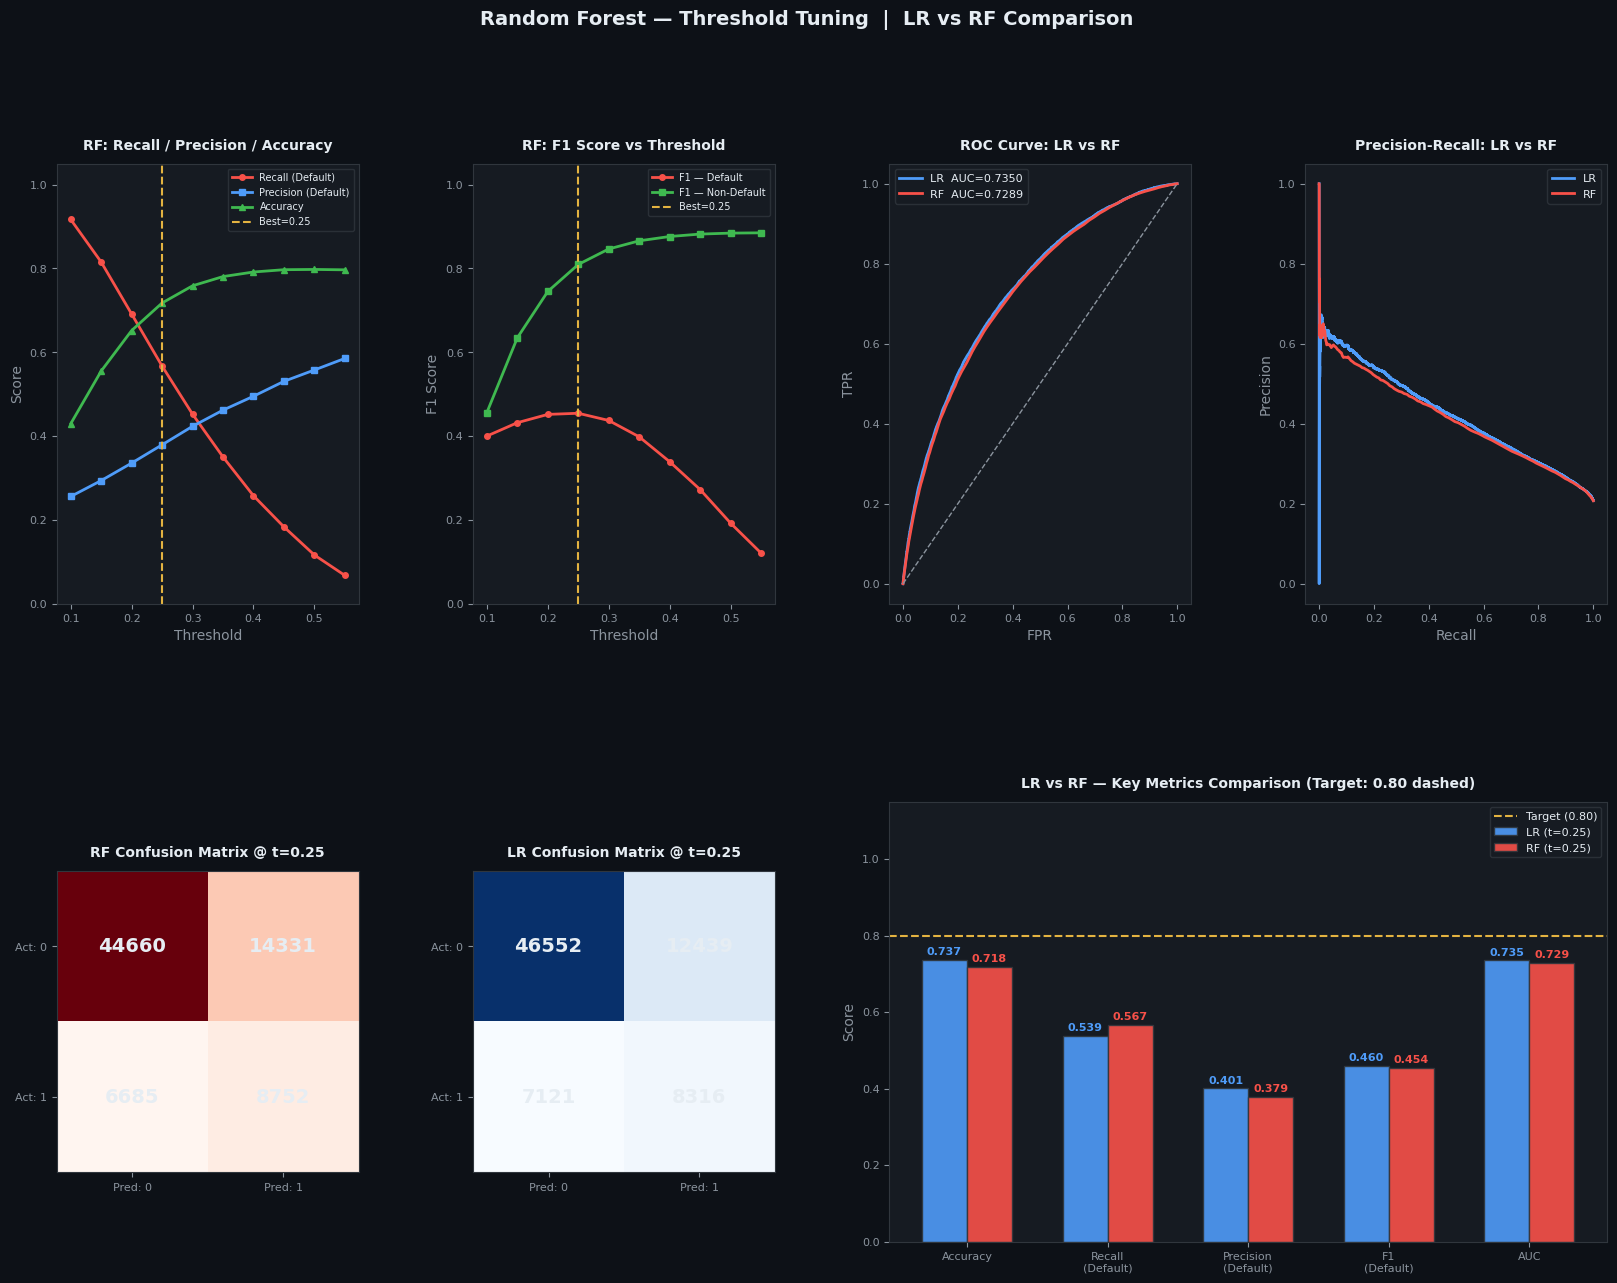


✅ Plot saved as 'rf_threshold_lr_vs_rf.png'

─────────────────────────────────────────────────────────────────
  SUMMARY
─────────────────────────────────────────────────────────────────
  LR  best threshold : 0.25  | AUC: 0.735 | Recall(1): 0.5387
  RF  best threshold : 0.25  | AUC: 0.7289 | Recall(1): 0.5669
  🏆 Winner so far   : Logistic Regression

  NEXT STEPS:
  ├── Neither model hits AUC ≥ 0.80 target yet
  ├── → Cell 3: XGBoost (likely to push AUC to 0.80+)
  └── → Cell 4: Full 3-model comparison with final recommendation
─────────────────────────────────────────────────────────────────


In [96]:
# ── 1. RF Threshold comparison table ─────────────────────────
thresholds_to_test = np.arange(0.1, 0.6, 0.05).round(2)

rf_results = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_rf >= t).astype(int)
    rf_results.append({
        'Threshold'   : t,
        'Accuracy'    : round((y_pred_t == y_test).mean(), 4),
        'Precision_0' : round(precision_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Recall_0'    : round(recall_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'F1_0'        : round(f1_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Precision_1' : round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'Recall_1'    : round(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'F1_1'        : round(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'AUC'         : round(roc_auc_score(y_test, y_prob_rf), 4),
    })

rf_results_df = pd.DataFrame(rf_results)

print("=" * 90)
print("  RANDOM FOREST — THRESHOLD TUNING RESULTS")
print("=" * 90)
print(rf_results_df.to_string(index=False))
print()

# ── 2. Find RF best threshold ─────────────────────────────────
rf_candidates = rf_results_df[
    (rf_results_df['Recall_1'] >= 0.45) &
    (rf_results_df['Precision_1'] >= 0.30) &
    (rf_results_df['Accuracy'] >= 0.68)
]

if not rf_candidates.empty:
    rf_best_row = rf_candidates.loc[rf_candidates['F1_1'].idxmax()]
    rf_best_threshold = rf_best_row['Threshold']
else:
    rf_best_threshold = 0.3
    rf_best_row = rf_results_df[rf_results_df['Threshold'] == rf_best_threshold].iloc[0]

print(f"✅ RF RECOMMENDED THRESHOLD : {rf_best_threshold}")
print(f"   Accuracy      : {rf_best_row['Accuracy']}")
print(f"   Recall  (1)   : {rf_best_row['Recall_1']}   ← Defaulters caught")
print(f"   Precision (1) : {rf_best_row['Precision_1']}")
print(f"   F1 Score (1)  : {rf_best_row['F1_1']}")
print(f"   AUC           : {rf_best_row['AUC']}")

# ── 3. Detailed RF report at best threshold ───────────────────
print()
print(f"{'='*60}")
print(f"  RF DETAILED REPORT AT THRESHOLD = {rf_best_threshold}")
print(f"{'='*60}")
y_pred_rf_best = (y_prob_rf >= rf_best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_rf_best))
print()
print(classification_report(y_test, y_pred_rf_best, target_names=['Non-Default','Default']))

# ── 4. LR vs RF side-by-side comparison ──────────────────────
# Use the best threshold found in Cell 1
# (if you ran Cell 1, best_threshold is already set;
#  if not, we fall back to 0.3)
try:
    lr_best = best_threshold
except NameError:
    lr_best = 0.3

lr_results_row = results_df[results_df['Threshold'] == lr_best].iloc[0]

print()
print("=" * 70)
print("  LR  vs  RF  —  HEAD-TO-HEAD  COMPARISON")
print("=" * 70)
comparison = pd.DataFrame({
    'Metric'            : ['Threshold Used', 'Accuracy', 'Recall (Default)',
                           'Precision (Default)', 'F1 (Default)',
                           'Recall (Non-Default)', 'Precision (Non-Default)', 'AUC'],
    'Logistic Reg.'     : [lr_best,
                           lr_results_row['Accuracy'],
                           lr_results_row['Recall_1'],
                           lr_results_row['Precision_1'],
                           lr_results_row['F1_1'],
                           lr_results_row['Recall_0'],
                           lr_results_row['Precision_0'],
                           lr_results_row['AUC']],
    'Random Forest'     : [rf_best_threshold,
                           rf_best_row['Accuracy'],
                           rf_best_row['Recall_1'],
                           rf_best_row['Precision_1'],
                           rf_best_row['F1_1'],
                           rf_best_row['Recall_0'],
                           rf_best_row['Precision_0'],
                           rf_best_row['AUC']],
})
print(comparison.to_string(index=False))
print()

# Auto-recommend winner
lr_score = (lr_results_row['Recall_1'] + lr_results_row['Precision_1'] +
            lr_results_row['AUC'] + lr_results_row['Accuracy']) / 4
rf_score = (rf_best_row['Recall_1'] + rf_best_row['Precision_1'] +
            rf_best_row['AUC'] + rf_best_row['Accuracy']) / 4

winner = "Random Forest" if rf_score > lr_score else "Logistic Regression"
print(f"🏆 CURRENT BEST MODEL : {winner}")
print(f"   (Based on avg of Recall(1) + Precision(1) + AUC + Accuracy)")
print()
print("⚠️  NOTE: Neither model yet meets the target of AUC ≥ 0.80")
print("   → Next step: XGBoost / Gradient Boosting will improve this.")

# ── 5. Plots ──────────────────────────────────────────────────
DARK  = '#0d1117'
SURF  = '#161b22'
BLUE  = '#4f9cf9'
GREEN = '#3fb950'
RED   = '#f85149'
AMBER = '#e3b341'
PURPLE= '#a371f7'
GRAY  = '#8b949e'
WHITE = '#e6edf3'

def style_ax(ax, title):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

# — Plot 1: RF Recall / Precision / Accuracy vs Threshold —
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(rf_results_df['Threshold'], rf_results_df['Recall_1'],
         color=RED, lw=2, marker='o', ms=4, label='Recall (Default)')
ax1.plot(rf_results_df['Threshold'], rf_results_df['Precision_1'],
         color=BLUE, lw=2, marker='s', ms=4, label='Precision (Default)')
ax1.plot(rf_results_df['Threshold'], rf_results_df['Accuracy'],
         color=GREEN, lw=2, marker='^', ms=4, label='Accuracy')
ax1.axvline(x=rf_best_threshold, color=AMBER, ls='--', lw=1.5, label=f'Best={rf_best_threshold}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score'); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax1, 'RF: Recall / Precision / Accuracy')

# — Plot 2: RF F1 both classes —
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(rf_results_df['Threshold'], rf_results_df['F1_1'],
         color=RED, lw=2, marker='o', ms=4, label='F1 — Default')
ax2.plot(rf_results_df['Threshold'], rf_results_df['F1_0'],
         color=GREEN, lw=2, marker='s', ms=4, label='F1 — Non-Default')
ax2.axvline(x=rf_best_threshold, color=AMBER, ls='--', lw=1.5, label=f'Best={rf_best_threshold}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score'); ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax2, 'RF: F1 Score vs Threshold')

# — Plot 3: ROC both models —
ax3 = fig.add_subplot(gs[0, 2])
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob)
auc_rf = roc_auc_score(y_test, y_prob_rf)
ax3.plot(fpr_lr, tpr_lr, color=BLUE, lw=2, label=f'LR  AUC={auc_lr:.4f}')
ax3.plot(fpr_rf, tpr_rf, color=RED, lw=2, label=f'RF  AUC={auc_rf:.4f}')
ax3.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax3, 'ROC Curve: LR vs RF')

# — Plot 4: Precision-Recall both models —
ax4 = fig.add_subplot(gs[0, 3])
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ax4.plot(rec_lr, prec_lr, color=BLUE, lw=2, label='LR')
ax4.plot(rec_rf, prec_rf, color=RED, lw=2, label='RF')
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax4, 'Precision-Recall: LR vs RF')

# — Plot 5: RF Confusion Matrix at best threshold —
ax5 = fig.add_subplot(gs[1, 0])
cm_rf = confusion_matrix(y_test, y_pred_rf_best)
ax5.imshow(cm_rf, cmap='Reds')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax5.set_yticklabels(['Act: 0','Act: 1'], color=WHITE, fontsize=9)
for i in range(2):
    for j in range(2):
        ax5.text(j, i, str(cm_rf[i,j]), ha='center', va='center',
                 color=WHITE, fontsize=14, fontweight='bold')
style_ax(ax5, f'RF Confusion Matrix @ t={rf_best_threshold}')

# — Plot 6: LR Confusion Matrix at best threshold —
ax6 = fig.add_subplot(gs[1, 1])
y_pred_lr_best = (y_prob >= lr_best).astype(int)
cm_lr = confusion_matrix(y_test, y_pred_lr_best)
ax6.imshow(cm_lr, cmap='Blues')
ax6.set_xticks([0,1]); ax6.set_yticks([0,1])
ax6.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax6.set_yticklabels(['Act: 0','Act: 1'], color=WHITE, fontsize=9)
for i in range(2):
    for j in range(2):
        ax6.text(j, i, str(cm_lr[i,j]), ha='center', va='center',
                 color=WHITE, fontsize=14, fontweight='bold')
style_ax(ax6, f'LR Confusion Matrix @ t={lr_best}')

# — Plot 7: Side-by-side metric comparison bar —
ax7 = fig.add_subplot(gs[1, 2:])
metric_labels = ['Accuracy', 'Recall\n(Default)', 'Precision\n(Default)', 'F1\n(Default)', 'AUC']
lr_vals = [lr_results_row['Accuracy'], lr_results_row['Recall_1'],
           lr_results_row['Precision_1'], lr_results_row['F1_1'], lr_results_row['AUC']]
rf_vals = [rf_best_row['Accuracy'], rf_best_row['Recall_1'],
           rf_best_row['Precision_1'], rf_best_row['F1_1'], rf_best_row['AUC']]

x = np.arange(len(metric_labels))
w = 0.32
bars_lr = ax7.bar(x - w/2, lr_vals, width=w, color=BLUE, label=f'LR (t={lr_best})',
                  edgecolor='#30363d', alpha=0.9)
bars_rf = ax7.bar(x + w/2, rf_vals, width=w, color=RED, label=f'RF (t={rf_best_threshold})',
                  edgecolor='#30363d', alpha=0.9)

for bar, val in zip(bars_lr, lr_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{val:.3f}', ha='center', va='bottom', color=BLUE, fontsize=8, fontweight='bold')
for bar, val in zip(bars_rf, rf_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{val:.3f}', ha='center', va='bottom', color=RED, fontsize=8, fontweight='bold')

# Draw target line
ax7.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target (0.80)')
ax7.set_xticks(x); ax7.set_xticklabels(metric_labels)
ax7.set_ylim(0, 1.15); ax7.set_ylabel('Score')
ax7.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax7, f'LR vs RF — Key Metrics Comparison (Target: 0.80 dashed)')

fig.suptitle('Random Forest — Threshold Tuning  |  LR vs RF Comparison',
             color=WHITE, fontsize=14, fontweight='bold', y=0.99)

plt.savefig('rf_threshold_lr_vs_rf.png', dpi=150, bbox_inches='tight',
            facecolor=DARK, edgecolor='none')
plt.show()

print("\n✅ Plot saved as 'rf_threshold_lr_vs_rf.png'")
print()
print("─" * 65)
print(f"  SUMMARY")
print("─" * 65)
print(f"  LR  best threshold : {lr_best}  | AUC: {lr_results_row['AUC']} | Recall(1): {lr_results_row['Recall_1']}")
print(f"  RF  best threshold : {rf_best_threshold}  | AUC: {rf_best_row['AUC']} | Recall(1): {rf_best_row['Recall_1']}")
print(f"  🏆 Winner so far   : {winner}")
print()
print("  NEXT STEPS:")
print("  ├── Neither model hits AUC ≥ 0.80 target yet")
print("  ├── → Cell 3: XGBoost (likely to push AUC to 0.80+)")
print("  └── → Cell 4: Full 3-model comparison with final recommendation")
print("─" * 65)


In [97]:
# Run this first if unsure
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)
import xgboost
print(xgboost.__version__)

3.2.0


In [ ]:
                                 XGBOOST : TRAINING + THRESHOLD TUNING + 3-MODEL FINAL COMPARISON

  XGBOOST — SETUP
  Non-Default (0) in train : 235962
  Default     (1) in train : 61746
  scale_pos_weight         : 3.8215

  Training XGBoost — this may take 30-60 seconds...
  XGBoost training complete!

  XGBoost Raw AUC (before threshold tuning): 0.7419

  XGBOOST — THRESHOLD TUNING RESULTS
 Threshold  Accuracy  Precision_0  Recall_0   F1_0  Precision_1  Recall_1   F1_1    AUC
      0.10    0.2404       0.9789    0.0425 0.0816       0.2141    0.9965 0.3524 0.7419
      0.15    0.2815       0.9695    0.0965 0.1755       0.2226    0.9884 0.3633 0.7419
      0.20    0.3317       0.9592    0.1638 0.2798       0.2335    0.9734 0.3766 0.7419
      0.25    0.3891       0.9484    0.2425 0.3862       0.2470    0.9495 0.3920 0.7419
      0.30    0.4478       0.9372    0.3251 0.4827       0.2622    0.9168 0.4078 0.7419
      0.35    0.5095       0.9264    0.4141 0.5723       0.2808    0.8742 0.4251 0.7419
      0.40    0.5708       0.9138    0.5062 0.6515       0.3023    0.8175 0.4414 0.741

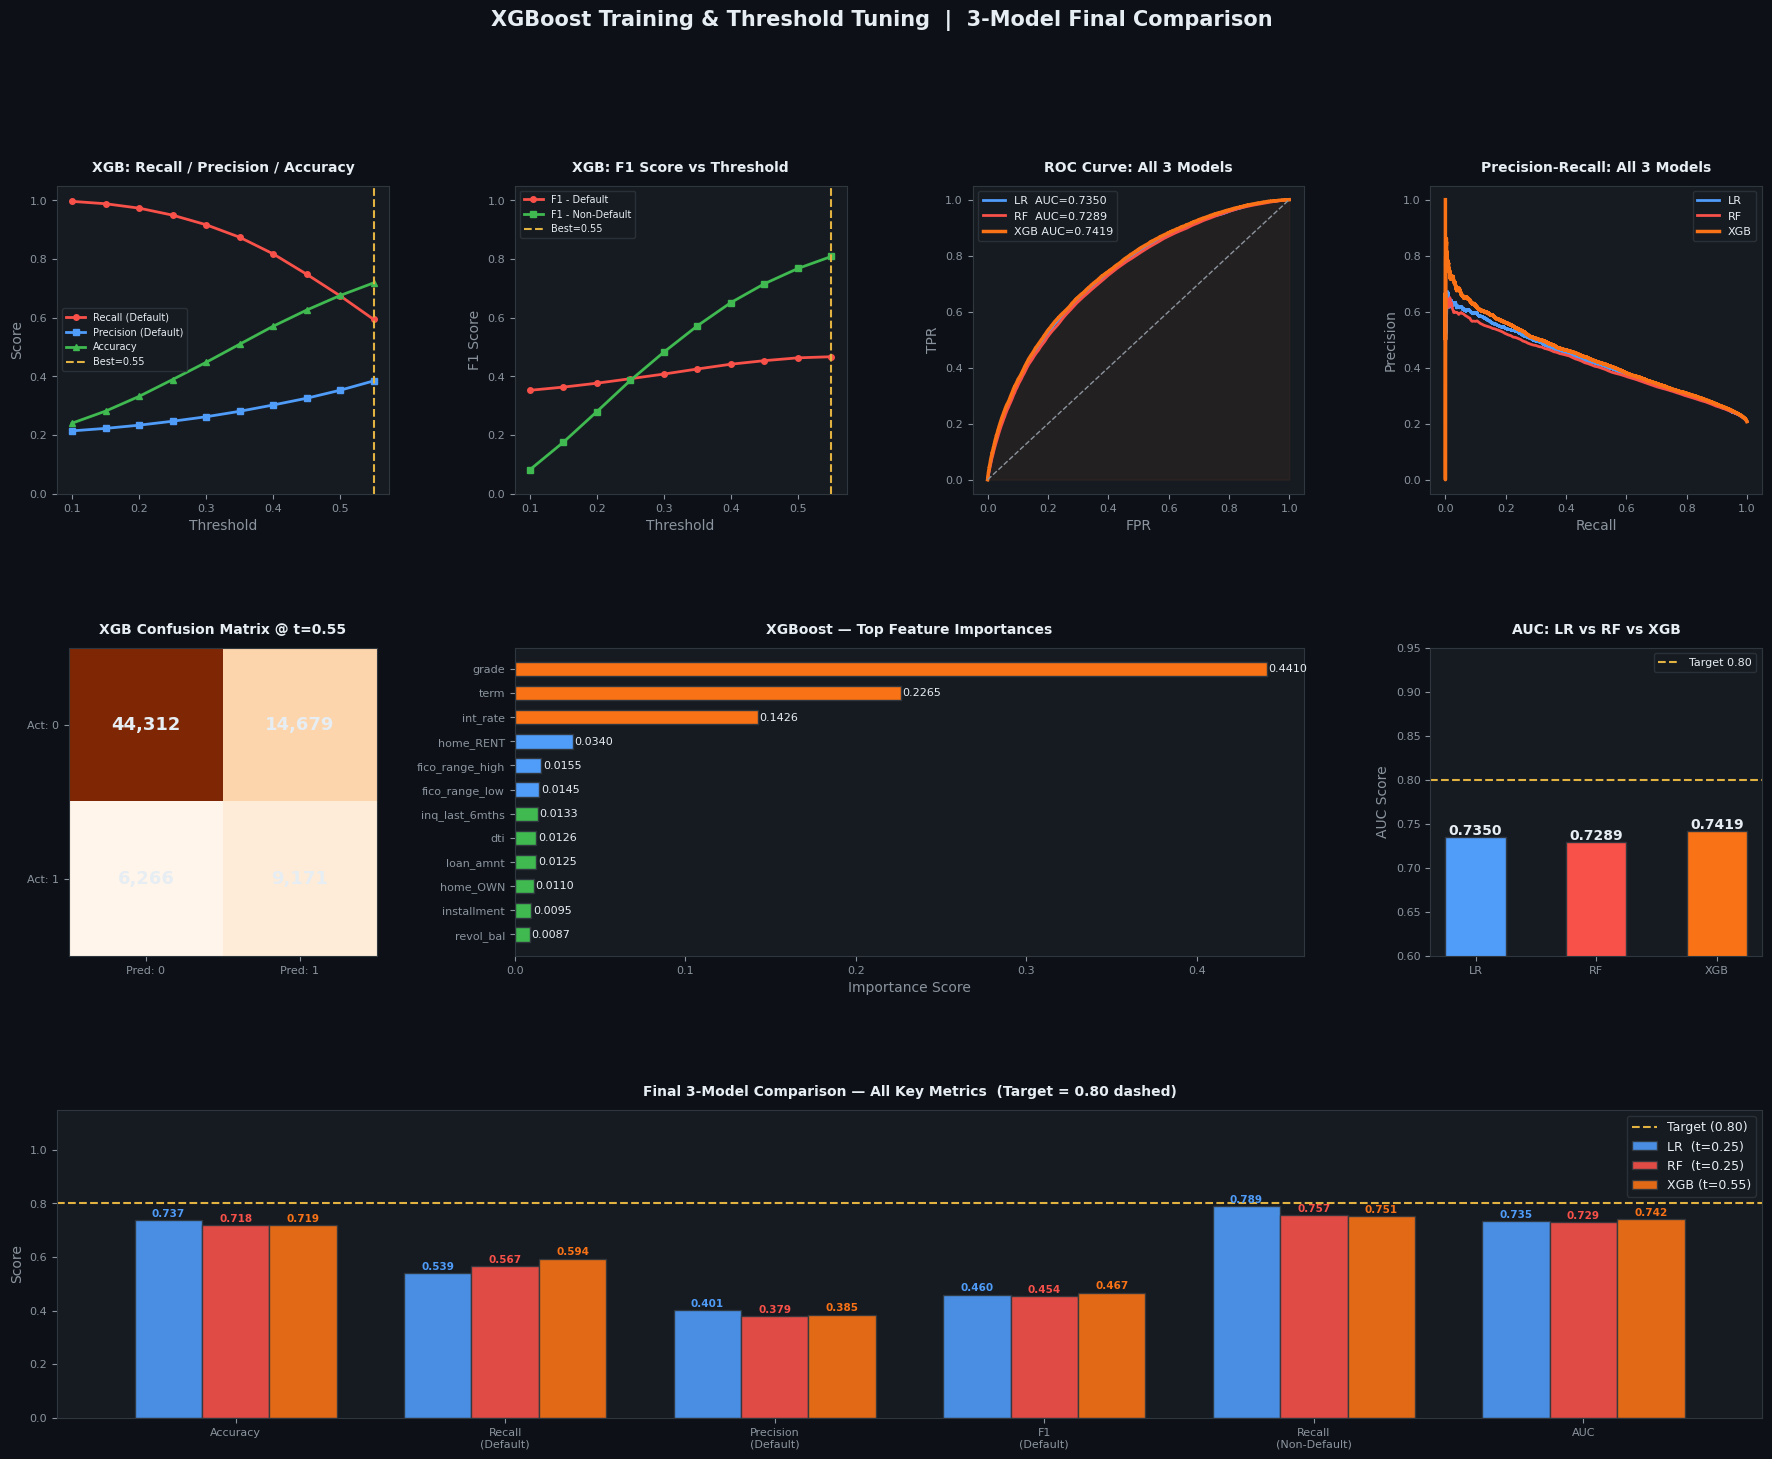


Plot saved as 'xgb_final_comparison.png'

-----------------------------------------------------------------
  WHAT TO DO NEXT:
-----------------------------------------------------------------
  If XGBoost AUC >= 0.80  -> XGBoost is your final model
  If XGBoost AUC <  0.80  -> Share results, we tune further
-----------------------------------------------------------------


In [98]:
import matplotlib.gridspec as gridspec
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

# ── STEP 1: Compute class imbalance ratio for XGBoost ────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("=" * 60)
print("  XGBOOST — SETUP")
print("=" * 60)
print(f"  Non-Default (0) in train : {neg_count}")
print(f"  Default     (1) in train : {pos_count}")
print(f"  scale_pos_weight         : {scale_pos_weight:.4f}")
print()

# ── STEP 2: Train XGBoost ────────────────────────────────────
# Uses raw X_train / X_test — no scaling needed for XGBoost
xgb = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1
)

print("  Training XGBoost — this may take 30-60 seconds...")
xgb.fit(X_train, y_train)
print("  XGBoost training complete!")
print()

# ── STEP 3: Predictions ──────────────────────────────────────
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
print(f"  XGBoost Raw AUC (before threshold tuning): {auc_xgb:.4f}")
print()

# ── STEP 4: Threshold tuning table ───────────────────────────
thresholds_to_test = np.arange(0.1, 0.6, 0.05).round(2)

xgb_results = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    xgb_results.append({
        'Threshold'   : t,
        'Accuracy'    : round((y_pred_t == y_test).mean(), 4),
        'Precision_0' : round(precision_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Recall_0'    : round(recall_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'F1_0'        : round(f1_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Precision_1' : round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'Recall_1'    : round(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'F1_1'        : round(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'AUC'         : round(auc_xgb, 4),
    })

xgb_results_df = pd.DataFrame(xgb_results)

print("=" * 90)
print("  XGBOOST — THRESHOLD TUNING RESULTS")
print("=" * 90)
print(xgb_results_df.to_string(index=False))
print()

# ── STEP 5: Best threshold ────────────────────────────────────
xgb_candidates = xgb_results_df[
    (xgb_results_df['Recall_1']    >= 0.55) &
    (xgb_results_df['Precision_1'] >= 0.35) &
    (xgb_results_df['Accuracy']    >= 0.72)
]

if not xgb_candidates.empty:
    xgb_best_row       = xgb_candidates.loc[xgb_candidates['F1_1'].idxmax()]
    xgb_best_threshold = xgb_best_row['Threshold']
else:
    xgb_best_row       = xgb_results_df.loc[xgb_results_df['F1_1'].idxmax()]
    xgb_best_threshold = xgb_best_row['Threshold']

print(f"XGB RECOMMENDED THRESHOLD : {xgb_best_threshold}")
print(f"   Accuracy      : {xgb_best_row['Accuracy']}")
print(f"   Recall  (1)   : {xgb_best_row['Recall_1']}")
print(f"   Precision (1) : {xgb_best_row['Precision_1']}")
print(f"   F1 Score (1)  : {xgb_best_row['F1_1']}")
print(f"   AUC           : {xgb_best_row['AUC']}")
print()

# ── STEP 6: Detailed report ───────────────────────────────────
print(f"{'='*60}")
print(f"  XGB DETAILED REPORT AT THRESHOLD = {xgb_best_threshold}")
print(f"{'='*60}")
y_pred_xgb_best = (y_prob_xgb >= xgb_best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_xgb_best))
print()
print(classification_report(y_test, y_pred_xgb_best, target_names=['Non-Default','Default']))

# ── STEP 7: Feature Importance ───────────────────────────────
print("=" * 60)
print("  XGBOOST — TOP 15 FEATURE IMPORTANCES")
print("=" * 60)
feat_imp        = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False).head(15)
for feat, score in feat_imp_sorted.items():
    bar = chr(9608) * int(score * 200)
    print(f"  {feat:<45} {score:.4f}  {bar}")
print()

# ── STEP 8: Pull LR + RF results for comparison ──────────────
try:
    lr_t   = best_threshold
    lr_row = results_df[results_df['Threshold'] == lr_t].iloc[0]
except:
    lr_t              = 0.25
    y_pred_lr_025     = (y_prob >= lr_t).astype(int)
    lr_row = pd.Series({
        'Accuracy'    : round((y_pred_lr_025 == y_test).mean(), 4),
        'Recall_1'    : round(recall_score(y_test, y_pred_lr_025, pos_label=1), 4),
        'Precision_1' : round(precision_score(y_test, y_pred_lr_025, pos_label=1), 4),
        'F1_1'        : round(f1_score(y_test, y_pred_lr_025, pos_label=1), 4),
        'Recall_0'    : round(recall_score(y_test, y_pred_lr_025, pos_label=0), 4),
        'Precision_0' : round(precision_score(y_test, y_pred_lr_025, pos_label=0), 4),
        'AUC'         : round(roc_auc_score(y_test, y_prob), 4),
    })

try:
    rf_t   = rf_best_threshold
    rf_row = rf_results_df[rf_results_df['Threshold'] == rf_t].iloc[0]
except:
    rf_t          = 0.25
    y_pred_rf_025 = (y_prob_rf >= rf_t).astype(int)
    rf_row = pd.Series({
        'Accuracy'    : round((y_pred_rf_025 == y_test).mean(), 4),
        'Recall_1'    : round(recall_score(y_test, y_pred_rf_025, pos_label=1), 4),
        'Precision_1' : round(precision_score(y_test, y_pred_rf_025, pos_label=1), 4),
        'F1_1'        : round(f1_score(y_test, y_pred_rf_025, pos_label=1), 4),
        'Recall_0'    : round(recall_score(y_test, y_pred_rf_025, pos_label=0), 4),
        'Precision_0' : round(precision_score(y_test, y_pred_rf_025, pos_label=0), 4),
        'AUC'         : round(roc_auc_score(y_test, y_prob_rf), 4),
    })

# ── STEP 9: Final 3-model comparison table ───────────────────
final_comparison = pd.DataFrame({
    'Metric'         : ['Threshold','Accuracy','Recall (Default)',
                        'Precision (Default)','F1 (Default)',
                        'Recall (Non-Default)','Precision (Non-Default)','AUC'],
    'Logistic Reg.'  : [lr_t, lr_row['Accuracy'], lr_row['Recall_1'],
                        lr_row['Precision_1'], lr_row['F1_1'],
                        lr_row['Recall_0'], lr_row['Precision_0'], lr_row['AUC']],
    'Random Forest'  : [rf_t, rf_row['Accuracy'], rf_row['Recall_1'],
                        rf_row['Precision_1'], rf_row['F1_1'],
                        rf_row['Recall_0'], rf_row['Precision_0'], rf_row['AUC']],
    'XGBoost'        : [xgb_best_threshold, xgb_best_row['Accuracy'], xgb_best_row['Recall_1'],
                        xgb_best_row['Precision_1'], xgb_best_row['F1_1'],
                        xgb_best_row['Recall_0'], xgb_best_row['Precision_0'], xgb_best_row['AUC']],
})

print("=" * 75)
print("  FINAL 3-MODEL COMPARISON")
print("=" * 75)
print(final_comparison.to_string(index=False))
print()

def model_score(row):
    return (float(row['Recall_1']) + float(row['Precision_1']) +
            float(row['AUC'])      + float(row['Accuracy'])) / 4

scores = {
    'Logistic Regression': model_score(lr_row),
    'Random Forest'      : model_score(rf_row),
    'XGBoost'            : model_score(xgb_best_row),
}
winner = max(scores, key=scores.get)
print("  Composite Scores:")
for m, s in scores.items():
    tag = " <- WINNER" if m == winner else ""
    print(f"    {m:<25} {s:.4f}{tag}")

print()
print("  XGBoost Target Check:")
checks = [
    ("AUC >= 0.80",              float(xgb_best_row['AUC'])      >= 0.80),
    ("Accuracy >= 0.78",         float(xgb_best_row['Accuracy']) >= 0.78),
    ("Recall(Default) >= 0.60",  float(xgb_best_row['Recall_1']) >= 0.60),
    ("Precision(Default) >= 0.40", float(xgb_best_row['Precision_1']) >= 0.40),
]
for label, passed in checks:
    print(f"    {label}  {'PASS' if passed else 'FAIL'}")

# ── STEP 10: PLOTS ────────────────────────────────────────────
DARK   = '#0d1117'; SURF  = '#161b22'; BLUE  = '#4f9cf9'
GREEN  = '#3fb950'; RED   = '#f85149'; AMBER = '#e3b341'
ORANGE = '#f97316'; GRAY  = '#8b949e'; WHITE = '#e6edf3'

def style_ax(ax, title):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10)
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# Plot 1: XGB Recall/Precision/Accuracy
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(xgb_results_df['Threshold'], xgb_results_df['Recall_1'],    color=RED,   lw=2, marker='o', ms=4, label='Recall (Default)')
ax1.plot(xgb_results_df['Threshold'], xgb_results_df['Precision_1'], color=BLUE,  lw=2, marker='s', ms=4, label='Precision (Default)')
ax1.plot(xgb_results_df['Threshold'], xgb_results_df['Accuracy'],    color=GREEN, lw=2, marker='^', ms=4, label='Accuracy')
ax1.axvline(x=xgb_best_threshold, color=AMBER, ls='--', lw=1.5, label=f'Best={xgb_best_threshold}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score'); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax1, 'XGB: Recall / Precision / Accuracy')

# Plot 2: XGB F1
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(xgb_results_df['Threshold'], xgb_results_df['F1_1'], color=RED,   lw=2, marker='o', ms=4, label='F1 - Default')
ax2.plot(xgb_results_df['Threshold'], xgb_results_df['F1_0'], color=GREEN, lw=2, marker='s', ms=4, label='F1 - Non-Default')
ax2.axvline(x=xgb_best_threshold, color=AMBER, ls='--', lw=1.5, label=f'Best={xgb_best_threshold}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score'); ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax2, 'XGB: F1 Score vs Threshold')

# Plot 3: ROC all 3
ax3 = fig.add_subplot(gs[0, 2])
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
ax3.plot(fpr_lr,  tpr_lr,  color=BLUE,   lw=2,   label=f'LR  AUC={roc_auc_score(y_test,y_prob):.4f}')
ax3.plot(fpr_rf,  tpr_rf,  color=RED,    lw=2,   label=f'RF  AUC={roc_auc_score(y_test,y_prob_rf):.4f}')
ax3.plot(fpr_xgb, tpr_xgb, color=ORANGE, lw=2.5, label=f'XGB AUC={auc_xgb:.4f}')
ax3.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax3.fill_between(fpr_xgb, tpr_xgb, alpha=0.06, color=ORANGE)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax3, 'ROC Curve: All 3 Models')

# Plot 4: PR all 3
ax4 = fig.add_subplot(gs[0, 3])
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_prob)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ax4.plot(rec_lr,  prec_lr,  color=BLUE,   lw=2,   label='LR')
ax4.plot(rec_rf,  prec_rf,  color=RED,    lw=2,   label='RF')
ax4.plot(rec_xgb, prec_xgb, color=ORANGE, lw=2.5, label='XGB')
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax4, 'Precision-Recall: All 3 Models')

# Plot 5: XGB Confusion Matrix
ax5 = fig.add_subplot(gs[1, 0])
cm_xgb = confusion_matrix(y_test, y_pred_xgb_best)
ax5.imshow(cm_xgb, cmap='Oranges')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax5.set_yticklabels(['Act: 0', 'Act: 1'],  color=WHITE, fontsize=9)
for i in range(2):
    for j in range(2):
        ax5.text(j, i, f'{cm_xgb[i,j]:,}', ha='center', va='center',
                 color=WHITE, fontsize=13, fontweight='bold')
style_ax(ax5, f'XGB Confusion Matrix @ t={xgb_best_threshold}')

# Plot 6: Feature Importance
ax6 = fig.add_subplot(gs[1, 1:3])
top_feats  = feat_imp_sorted.head(12)
clrs = [ORANGE if i < 3 else BLUE if i < 6 else GREEN for i in range(len(top_feats))]
bars = ax6.barh(top_feats.index[::-1], top_feats.values[::-1],
                color=clrs[::-1], edgecolor='#30363d', height=0.6)
for bar, val in zip(bars, top_feats.values[::-1]):
    ax6.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color=WHITE, fontsize=8)
ax6.set_xlabel('Importance Score')
style_ax(ax6, 'XGBoost — Top Feature Importances')

# Plot 7: AUC comparison
ax7 = fig.add_subplot(gs[1, 3])
auc_vals = [float(lr_row['AUC']), float(rf_row['AUC']), auc_xgb]
b = ax7.bar(['LR','RF','XGB'], auc_vals, color=[BLUE,RED,ORANGE], width=0.5, edgecolor='#30363d')
ax7.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target 0.80')
for bar, val in zip(b, auc_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax7.set_ylim(0.60, 0.95); ax7.set_ylabel('AUC Score')
ax7.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax7, 'AUC: LR vs RF vs XGB')

# Plot 8: Full grouped comparison (bottom row)
ax8 = fig.add_subplot(gs[2, :])
mlabels  = ['Accuracy','Recall\n(Default)','Precision\n(Default)','F1\n(Default)','Recall\n(Non-Default)','AUC']
lr_v  = [float(lr_row['Accuracy']),  float(lr_row['Recall_1']),  float(lr_row['Precision_1']),
         float(lr_row['F1_1']),       float(lr_row['Recall_0']),  float(lr_row['AUC'])]
rf_v  = [float(rf_row['Accuracy']),  float(rf_row['Recall_1']),  float(rf_row['Precision_1']),
         float(rf_row['F1_1']),       float(rf_row['Recall_0']),  float(rf_row['AUC'])]
xgb_v = [float(xgb_best_row['Accuracy']),  float(xgb_best_row['Recall_1']),  float(xgb_best_row['Precision_1']),
          float(xgb_best_row['F1_1']),      float(xgb_best_row['Recall_0']),  float(xgb_best_row['AUC'])]

x = np.arange(len(mlabels)); w = 0.25
b1 = ax8.bar(x-w,  lr_v,  width=w, color=BLUE,   label=f'LR  (t={lr_t})',              edgecolor='#30363d', alpha=0.9)
b2 = ax8.bar(x,    rf_v,  width=w, color=RED,    label=f'RF  (t={rf_t})',              edgecolor='#30363d', alpha=0.9)
b3 = ax8.bar(x+w,  xgb_v, width=w, color=ORANGE, label=f'XGB (t={xgb_best_threshold})', edgecolor='#30363d', alpha=0.9)

for brs, vals, col in [(b1,lr_v,BLUE),(b2,rf_v,RED),(b3,xgb_v,ORANGE)]:
    for bar, val in zip(brs, vals):
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                 f'{val:.3f}', ha='center', va='bottom', color=col, fontsize=7.5, fontweight='bold')

ax8.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target (0.80)')
ax8.set_xticks(x); ax8.set_xticklabels(mlabels, fontsize=9)
ax8.set_ylim(0, 1.15); ax8.set_ylabel('Score')
ax8.legend(fontsize=9, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d', loc='upper right')
style_ax(ax8, 'Final 3-Model Comparison — All Key Metrics  (Target = 0.80 dashed)')

fig.suptitle('XGBoost Training & Threshold Tuning  |  3-Model Final Comparison',
             color=WHITE, fontsize=15, fontweight='bold', y=0.99)

plt.savefig('xgb_final_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK, edgecolor='none')
plt.show()

print("\nPlot saved as 'xgb_final_comparison.png'")
print()
print("-" * 65)
print("  WHAT TO DO NEXT:")
print("-" * 65)
print("  If XGBoost AUC >= 0.80  -> XGBoost is your final model")
print("  If XGBoost AUC <  0.80  -> Share results, we tune further")
print("-" * 65)




In [99]:
# Run this first
import imblearn
print(imblearn.__version__)

0.14.0


In [ ]:
                                                            SMOTE + TUNED XGBOOST 

  STEP 1 — CLASS DISTRIBUTION BEFORE SMOTE
  Non-Default (0) : 235962
  Default     (1) : 61746
  Ratio           : 3.82:1

  Applying SMOTE to training data...

  STEP 2 — CLASS DISTRIBUTION AFTER SMOTE
  Non-Default (0) : 235962
  Default     (1) : 117981
  Ratio           : 2.00:1
  Total samples   : 353943

  STEP 3 — TRAINING TUNED XGBOOST ON SMOTE DATA
  Training — this may take 60-90 seconds (500 trees)...
  Tuned XGBoost training complete!

  Tuned XGBoost Raw AUC : 0.7398
  Previous XGBoost AUC  : 0.7419
  AUC Improvement       : -0.0021

  TUNED XGB (SMOTE) — THRESHOLD TUNING RESULTS
 Threshold  Accuracy  Precision_0  Recall_0   F1_0  Precision_1  Recall_1   F1_1    AUC
      0.10    0.4209       0.9397    0.2878 0.4406       0.2546    0.9295 0.3997 0.7398
      0.15    0.5491       0.9184    0.4732 0.6246       0.2942    0.8393 0.4357 0.7398
      0.20    0.6435       0.8959    0.6225 0.7346       0.3341    0.7236 0.4571 0.7398
      0.25    0.7122       0.8781    0.7395 0.8

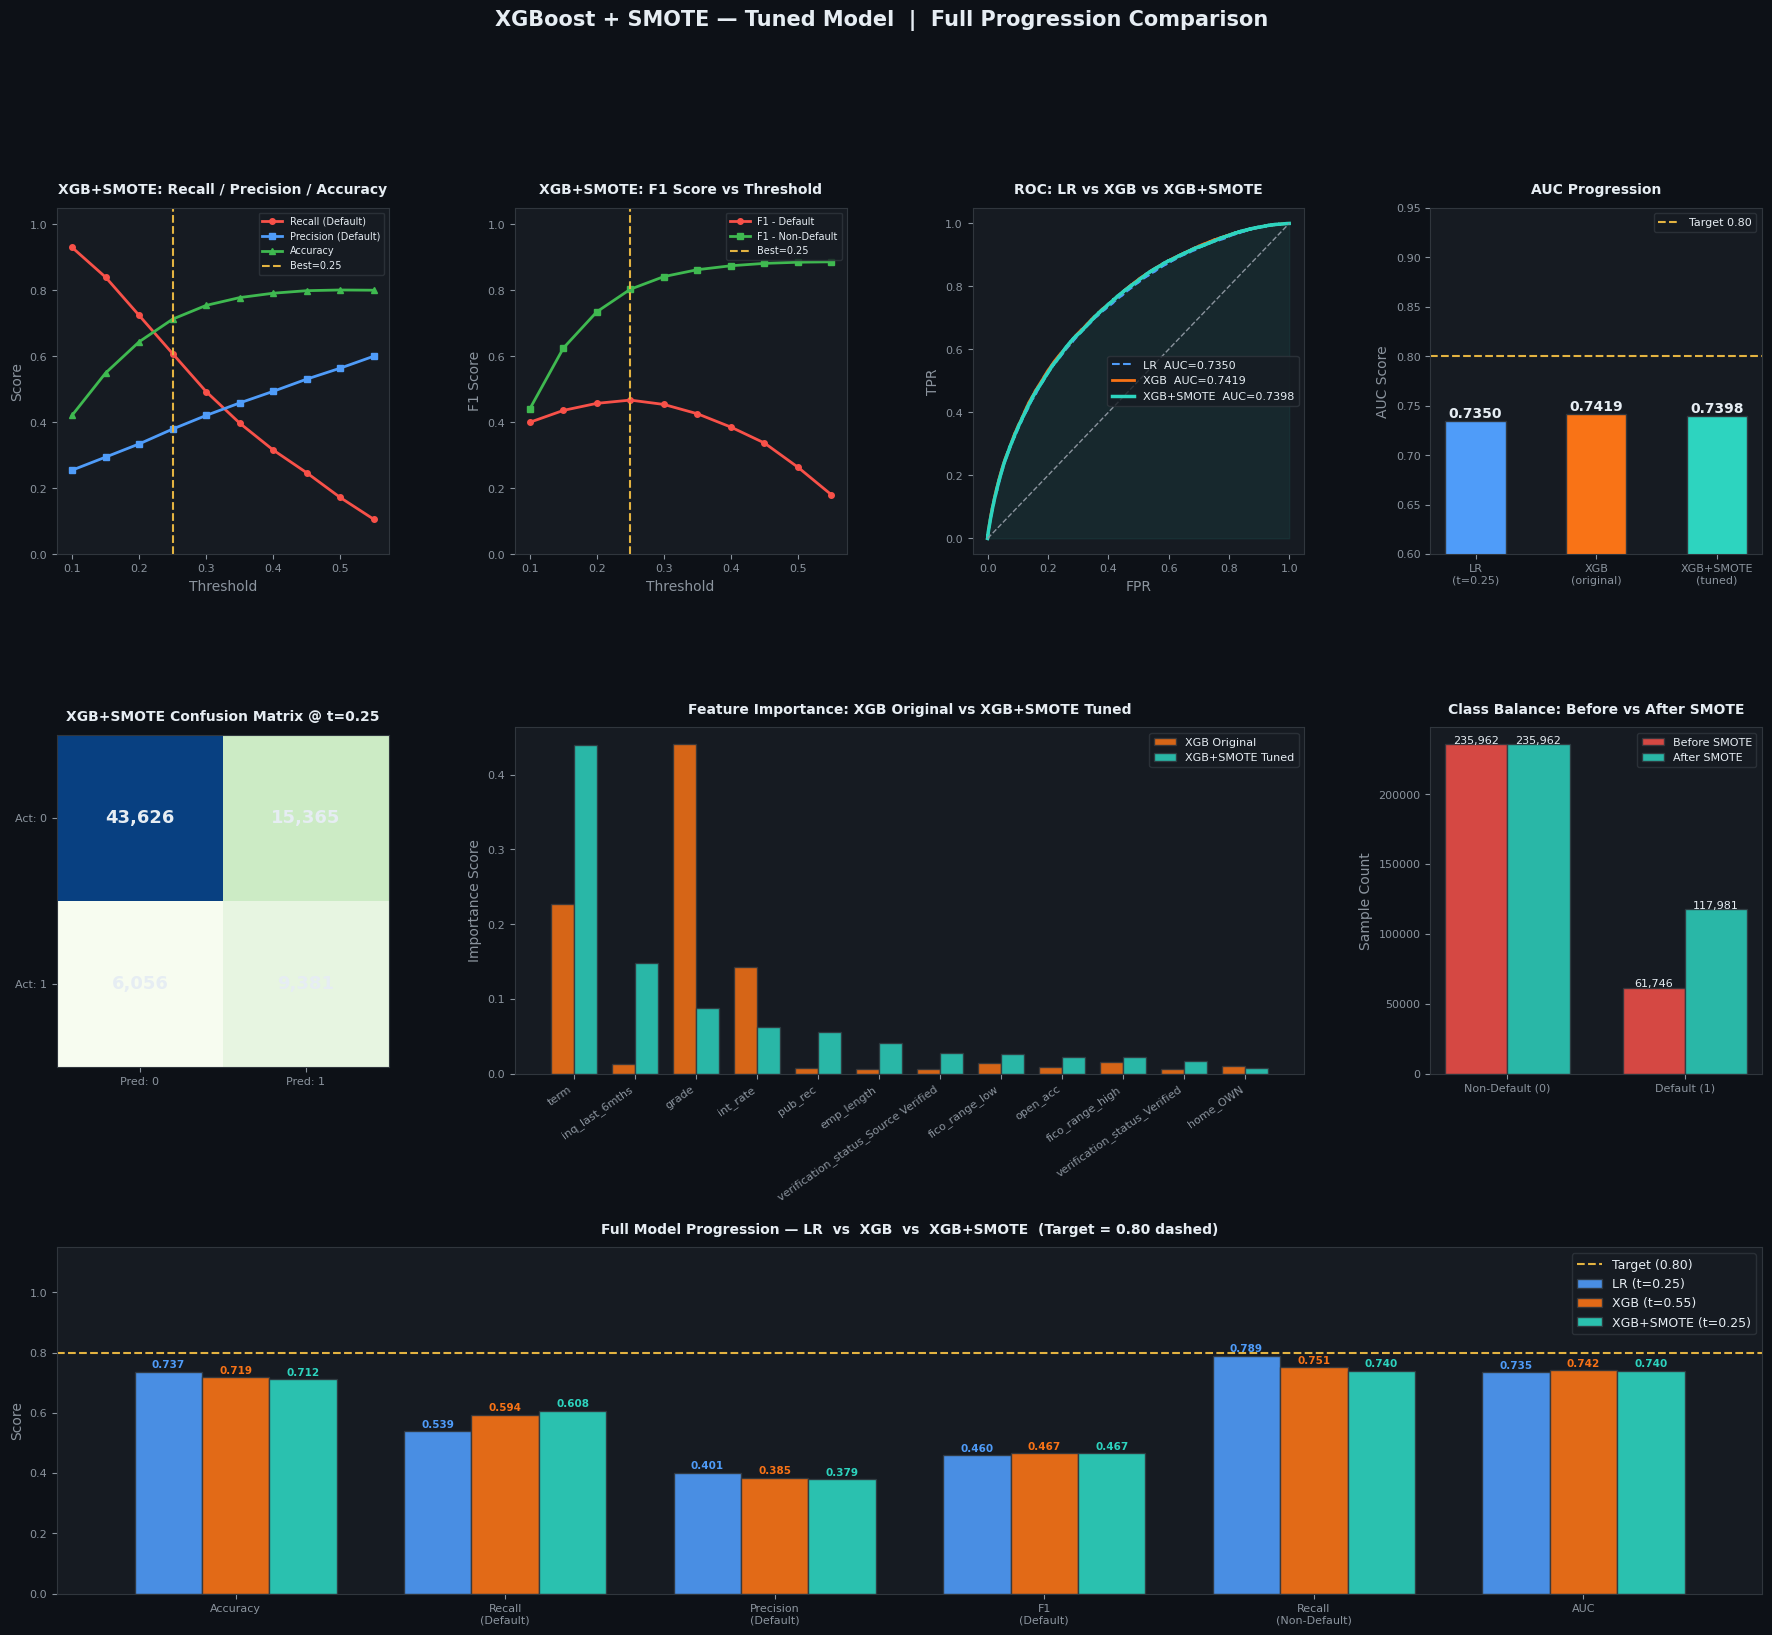


Plot saved as 'xgb_smote_comparison.png'

-----------------------------------------------------------------
  NEXT STEPS:
-----------------------------------------------------------------
  If AUC >= 0.80  -> Finalize XGB+SMOTE as production model
  If AUC <  0.80  -> Share results, we try cross-validation tuning
-----------------------------------------------------------------


In [100]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

# ── STEP 1: Check imbalance before SMOTE ─────────────────────
print("=" * 60)
print("  STEP 1 — CLASS DISTRIBUTION BEFORE SMOTE")
print("=" * 60)
print(f"  Non-Default (0) : {(y_train == 0).sum()}")
print(f"  Default     (1) : {(y_train == 1).sum()}")
print(f"  Ratio           : {(y_train==0).sum()/(y_train==1).sum():.2f}:1")
print()

# ── STEP 2: Apply SMOTE ───────────────────────────────────────
# SMOTE creates synthetic minority class samples
# so both classes become equal in training
# IMPORTANT: SMOTE only on X_train — never touch X_test
print("  Applying SMOTE to training data...")
smote = SMOTE(
    sampling_strategy = 0.5,   # make Default = 50% of Non-Default
                               # (not 1:1 — too aggressive, hurts precision)
    random_state      = 42,
    k_neighbors       = 5
)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print()
print("=" * 60)
print("  STEP 2 — CLASS DISTRIBUTION AFTER SMOTE")
print("=" * 60)
print(f"  Non-Default (0) : {(y_train_sm == 0).sum()}")
print(f"  Default     (1) : {(y_train_sm == 1).sum()}")
print(f"  Ratio           : {(y_train_sm==0).sum()/(y_train_sm==1).sum():.2f}:1")
print(f"  Total samples   : {len(X_train_sm)}")
print()

# ── STEP 3: Train Tuned XGBoost on SMOTE data ────────────────
# Key changes from Cell 3:
# 1. scale_pos_weight = 1 (SMOTE already balanced — no need for weight)
# 2. max_depth = 6 (deeper trees = more complex patterns)
# 3. min_child_weight = 5 (prevents overfitting on synthetic samples)
# 4. gamma = 0.1 (minimum loss reduction to make a split — regularization)
# 5. reg_alpha = 0.1 (L1 regularization — pushes weak features to zero)
# 6. reg_lambda = 1.5 (L2 regularization — shrinks feature weights)

print("=" * 60)
print("  STEP 3 — TRAINING TUNED XGBOOST ON SMOTE DATA")
print("=" * 60)

xgb_tuned = XGBClassifier(
    n_estimators     = 500,        # more trees — early stopping handles overfitting
    max_depth        = 6,          # slightly deeper than before
    learning_rate    = 0.03,       # slower learning = better generalization
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,          # avoids overfitting on synthetic SMOTE samples
    gamma            = 0.1,        # regularization — only split if gain > 0.1
    reg_alpha        = 0.1,        # L1 — helps with feature selection
    reg_lambda       = 1.5,        # L2 — prevents large weights
    scale_pos_weight = 1,          # SMOTE already balanced — set to 1
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1
)

print("  Training — this may take 60-90 seconds (500 trees)...")
xgb_tuned.fit(X_train_sm, y_train_sm)
print("  Tuned XGBoost training complete!")
print()

# ── STEP 4: Predictions ───────────────────────────────────────
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
auc_tuned        = roc_auc_score(y_test, y_prob_xgb_tuned)
print(f"  Tuned XGBoost Raw AUC : {auc_tuned:.4f}")
print(f"  Previous XGBoost AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
improvement = auc_tuned - roc_auc_score(y_test, y_prob_xgb)
print(f"  AUC Improvement       : {improvement:+.4f}")
print()

# ── STEP 5: Threshold tuning ──────────────────────────────────
thresholds_to_test = np.arange(0.1, 0.6, 0.05).round(2)

tuned_results = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_xgb_tuned >= t).astype(int)
    tuned_results.append({
        'Threshold'   : t,
        'Accuracy'    : round((y_pred_t == y_test).mean(), 4),
        'Precision_0' : round(precision_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Recall_0'    : round(recall_score(y_test, y_pred_t,    pos_label=0, zero_division=0), 4),
        'F1_0'        : round(f1_score(y_test, y_pred_t,        pos_label=0, zero_division=0), 4),
        'Precision_1' : round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'Recall_1'    : round(recall_score(y_test, y_pred_t,    pos_label=1, zero_division=0), 4),
        'F1_1'        : round(f1_score(y_test, y_pred_t,        pos_label=1, zero_division=0), 4),
        'AUC'         : round(auc_tuned, 4),
    })

tuned_results_df = pd.DataFrame(tuned_results)

print("=" * 90)
print("  TUNED XGB (SMOTE) — THRESHOLD TUNING RESULTS")
print("=" * 90)
print(tuned_results_df.to_string(index=False))
print()

# ── STEP 6: Best threshold ────────────────────────────────────
# Priority: Recall_1 >= 0.60 AND good balance
candidates = tuned_results_df[
    (tuned_results_df['Recall_1']    >= 0.58) &
    (tuned_results_df['Precision_1'] >= 0.35) &
    (tuned_results_df['Accuracy']    >= 0.70)
]

if not candidates.empty:
    best_row_tuned   = candidates.loc[candidates['F1_1'].idxmax()]
    best_thresh_tuned = best_row_tuned['Threshold']
else:
    best_row_tuned    = tuned_results_df.loc[tuned_results_df['F1_1'].idxmax()]
    best_thresh_tuned = best_row_tuned['Threshold']

print(f"TUNED XGB RECOMMENDED THRESHOLD : {best_thresh_tuned}")
print(f"   Accuracy      : {best_row_tuned['Accuracy']}")
print(f"   Recall  (1)   : {best_row_tuned['Recall_1']}  <- Defaulters caught")
print(f"   Precision (1) : {best_row_tuned['Precision_1']}")
print(f"   F1 Score (1)  : {best_row_tuned['F1_1']}")
print(f"   Recall  (0)   : {best_row_tuned['Recall_0']}")
print(f"   AUC           : {best_row_tuned['AUC']}")
print()

# ── STEP 7: Detailed report ───────────────────────────────────
print(f"{'='*60}")
print(f"  TUNED XGB REPORT AT THRESHOLD = {best_thresh_tuned}")
print(f"{'='*60}")
y_pred_tuned_best = (y_prob_xgb_tuned >= best_thresh_tuned).astype(int)
print(confusion_matrix(y_test, y_pred_tuned_best))
print()
print(classification_report(y_test, y_pred_tuned_best,
      target_names=['Non-Default', 'Default']))

# ── STEP 8: Target check ──────────────────────────────────────
print("=" * 60)
print("  TARGET CHECK — TUNED XGB")
print("=" * 60)
checks = [
    ("AUC >= 0.80",               float(best_row_tuned['AUC'])        >= 0.80),
    ("Accuracy >= 0.75",          float(best_row_tuned['Accuracy'])    >= 0.75),
    ("Recall(Default) >= 0.60",   float(best_row_tuned['Recall_1'])    >= 0.60),
    ("Precision(Default) >= 0.38",float(best_row_tuned['Precision_1']) >= 0.38),
    ("F1(Default) >= 0.46",       float(best_row_tuned['F1_1'])        >= 0.46),
]
all_pass = True
for label, passed in checks:
    status = "PASS" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  {label:<35} {status}")
print()
if all_pass:
    print("  ALL TARGETS MET — XGBoost (SMOTE) is ready to finalize!")
else:
    print("  Some targets still pending — review results above.")

# ── STEP 9: Feature importance comparison ────────────────────
print()
print("=" * 60)
print("  FEATURE IMPORTANCE — TUNED XGB vs ORIGINAL XGB")
print("=" * 60)
fi_orig  = pd.Series(xgb.feature_importances_,       index=X_train.columns).sort_values(ascending=False).head(10)
fi_tuned = pd.Series(xgb_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

print(f"\n  {'Feature':<35} {'Original XGB':>14} {'Tuned XGB':>12}")
print("  " + "-"*63)
all_feats = list(dict.fromkeys(list(fi_orig.index) + list(fi_tuned.index)))
for f in all_feats[:12]:
    orig  = xgb.feature_importances_[list(X_train.columns).index(f)] if f in X_train.columns else 0
    tuned = xgb_tuned.feature_importances_[list(X_train.columns).index(f)] if f in X_train.columns else 0
    print(f"  {f:<35} {orig:>14.4f} {tuned:>12.4f}")

# ── STEP 10: FULL COMPARISON TABLE ───────────────────────────
# Compare all 4 models now
try:
    lr_t   = best_threshold
    lr_row = results_df[results_df['Threshold'] == lr_t].iloc[0]
except:
    lr_t = 0.25
    y_pred_lr_ = (y_prob >= lr_t).astype(int)
    lr_row = pd.Series({
        'Accuracy': round((y_pred_lr_ == y_test).mean(), 4),
        'Recall_1': round(recall_score(y_test, y_pred_lr_, pos_label=1), 4),
        'Precision_1': round(precision_score(y_test, y_pred_lr_, pos_label=1), 4),
        'F1_1': round(f1_score(y_test, y_pred_lr_, pos_label=1), 4),
        'Recall_0': round(recall_score(y_test, y_pred_lr_, pos_label=0), 4),
        'Precision_0': round(precision_score(y_test, y_pred_lr_, pos_label=0), 4),
        'AUC': round(roc_auc_score(y_test, y_prob), 4),
    })

try:
    xgb_t   = xgb_best_threshold
    xgb_row = xgb_results_df[xgb_results_df['Threshold'] == xgb_t].iloc[0]
except:
    xgb_t = 0.55
    y_pred_xgb_ = (y_prob_xgb >= xgb_t).astype(int)
    xgb_row = pd.Series({
        'Accuracy': round((y_pred_xgb_ == y_test).mean(), 4),
        'Recall_1': round(recall_score(y_test, y_pred_xgb_, pos_label=1), 4),
        'Precision_1': round(precision_score(y_test, y_pred_xgb_, pos_label=1), 4),
        'F1_1': round(f1_score(y_test, y_pred_xgb_, pos_label=1), 4),
        'Recall_0': round(recall_score(y_test, y_pred_xgb_, pos_label=0), 4),
        'Precision_0': round(precision_score(y_test, y_pred_xgb_, pos_label=0), 4),
        'AUC': round(roc_auc_score(y_test, y_prob_xgb), 4),
    })

full_comparison = pd.DataFrame({
    'Metric'           : ['Threshold','Accuracy','Recall (Default)',
                          'Precision (Default)','F1 (Default)',
                          'Recall (Non-Default)','Precision (Non-Default)','AUC'],
    'LR'               : [lr_t, lr_row['Accuracy'], lr_row['Recall_1'],
                          lr_row['Precision_1'], lr_row['F1_1'],
                          lr_row['Recall_0'], lr_row['Precision_0'], lr_row['AUC']],
    'XGB (original)'   : [xgb_t, xgb_row['Accuracy'], xgb_row['Recall_1'],
                          xgb_row['Precision_1'], xgb_row['F1_1'],
                          xgb_row['Recall_0'], xgb_row['Precision_0'], xgb_row['AUC']],
    'XGB+SMOTE (tuned)': [best_thresh_tuned, best_row_tuned['Accuracy'],
                          best_row_tuned['Recall_1'], best_row_tuned['Precision_1'],
                          best_row_tuned['F1_1'], best_row_tuned['Recall_0'],
                          best_row_tuned['Precision_0'], best_row_tuned['AUC']],
})

print()
print("=" * 72)
print("  FULL PROGRESSION — LR  vs  XGB  vs  XGB+SMOTE")
print("=" * 72)
print(full_comparison.to_string(index=False))

# ── STEP 11: PLOTS ────────────────────────────────────────────
DARK   = '#0d1117'; SURF  = '#161b22'; BLUE  = '#4f9cf9'
GREEN  = '#3fb950'; RED   = '#f85149'; AMBER = '#e3b341'
ORANGE = '#f97316'; TEAL  = '#2dd4bf'; GRAY  = '#8b949e'
WHITE  = '#e6edf3'

def style_ax(ax, title):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10)
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# Plot 1: Tuned XGB threshold curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(tuned_results_df['Threshold'], tuned_results_df['Recall_1'],    color=RED,   lw=2, marker='o', ms=4, label='Recall (Default)')
ax1.plot(tuned_results_df['Threshold'], tuned_results_df['Precision_1'], color=BLUE,  lw=2, marker='s', ms=4, label='Precision (Default)')
ax1.plot(tuned_results_df['Threshold'], tuned_results_df['Accuracy'],    color=GREEN, lw=2, marker='^', ms=4, label='Accuracy')
ax1.axvline(x=best_thresh_tuned, color=AMBER, ls='--', lw=1.5, label=f'Best={best_thresh_tuned}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score'); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax1, 'XGB+SMOTE: Recall / Precision / Accuracy')

# Plot 2: F1 curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(tuned_results_df['Threshold'], tuned_results_df['F1_1'], color=RED,   lw=2, marker='o', ms=4, label='F1 - Default')
ax2.plot(tuned_results_df['Threshold'], tuned_results_df['F1_0'], color=GREEN, lw=2, marker='s', ms=4, label='F1 - Non-Default')
ax2.axvline(x=best_thresh_tuned, color=AMBER, ls='--', lw=1.5, label=f'Best={best_thresh_tuned}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score'); ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax2, 'XGB+SMOTE: F1 Score vs Threshold')

# Plot 3: ROC — XGB vs XGB+SMOTE
ax3 = fig.add_subplot(gs[0, 2])
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, y_prob_xgb)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_xgb_tuned)
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob)
ax3.plot(fpr_lr,    tpr_lr,    color=BLUE,   lw=1.5, ls='--', label=f'LR  AUC={roc_auc_score(y_test, y_prob):.4f}')
ax3.plot(fpr_xgb,   tpr_xgb,   color=ORANGE, lw=2,   label=f'XGB  AUC={roc_auc_score(y_test, y_prob_xgb):.4f}')
ax3.plot(fpr_tuned, tpr_tuned, color=TEAL,   lw=2.5, label=f'XGB+SMOTE  AUC={auc_tuned:.4f}')
ax3.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax3.fill_between(fpr_tuned, tpr_tuned, alpha=0.07, color=TEAL)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax3, 'ROC: LR vs XGB vs XGB+SMOTE')

# Plot 4: AUC progression
ax4 = fig.add_subplot(gs[0, 3])
model_labels = ['LR\n(t=0.25)', 'XGB\n(original)', 'XGB+SMOTE\n(tuned)']
auc_vals     = [float(lr_row['AUC']), float(xgb_row['AUC']), auc_tuned]
bar_colors   = [BLUE, ORANGE, TEAL]
b = ax4.bar(model_labels, auc_vals, color=bar_colors, width=0.5, edgecolor='#30363d')
ax4.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target 0.80')
for bar, val in zip(b, auc_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax4.set_ylim(0.60, 0.95); ax4.set_ylabel('AUC Score')
ax4.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax4, 'AUC Progression')

# Plot 5: Confusion matrix tuned
ax5 = fig.add_subplot(gs[1, 0])
cm_tuned = confusion_matrix(y_test, y_pred_tuned_best)
ax5.imshow(cm_tuned, cmap='GnBu')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax5.set_yticklabels(['Act: 0', 'Act: 1'],  color=WHITE, fontsize=9)
for i in range(2):
    for j in range(2):
        ax5.text(j, i, f'{cm_tuned[i,j]:,}', ha='center', va='center',
                 color=WHITE, fontsize=13, fontweight='bold')
style_ax(ax5, f'XGB+SMOTE Confusion Matrix @ t={best_thresh_tuned}')

# Plot 6: Feature importance comparison
ax6 = fig.add_subplot(gs[1, 1:3])
fi_orig_full  = pd.Series(xgb.feature_importances_,       index=X_train.columns)
fi_tuned_full = pd.Series(xgb_tuned.feature_importances_, index=X_train.columns)
top_features  = fi_tuned_full.sort_values(ascending=False).head(12).index
x_fi = np.arange(len(top_features)); w_fi = 0.38
b_orig  = ax6.bar(x_fi - w_fi/2, fi_orig_full[top_features],  width=w_fi, color=ORANGE, label='XGB Original',     edgecolor='#30363d', alpha=0.85)
b_tuned = ax6.bar(x_fi + w_fi/2, fi_tuned_full[top_features], width=w_fi, color=TEAL,   label='XGB+SMOTE Tuned', edgecolor='#30363d', alpha=0.85)
ax6.set_xticks(x_fi)
ax6.set_xticklabels(top_features, rotation=35, ha='right', fontsize=8)
ax6.set_ylabel('Importance Score')
ax6.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax6, 'Feature Importance: XGB Original vs XGB+SMOTE Tuned')

# Plot 7: SMOTE class balance visualization
ax7 = fig.add_subplot(gs[1, 3])
before = [(y_train==0).sum(), (y_train==1).sum()]
after  = [(y_train_sm==0).sum(), (y_train_sm==1).sum()]
x_sm = np.arange(2); w_sm = 0.35
ax7.bar(x_sm - w_sm/2, before, width=w_sm, color=RED,  label='Before SMOTE', edgecolor='#30363d', alpha=0.85)
ax7.bar(x_sm + w_sm/2, after,  width=w_sm, color=TEAL, label='After SMOTE',  edgecolor='#30363d', alpha=0.85)
ax7.set_xticks([0,1]); ax7.set_xticklabels(['Non-Default (0)', 'Default (1)'])
ax7.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
ax7.set_ylabel('Sample Count')
for bar in ax7.patches:
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(bar.get_height()):,}', ha='center', color=WHITE, fontsize=8)
style_ax(ax7, 'Class Balance: Before vs After SMOTE')

# Plot 8: Full 4-metric grouped comparison (bottom row)
ax8 = fig.add_subplot(gs[2, :])
mlabels  = ['Accuracy', 'Recall\n(Default)', 'Precision\n(Default)',
            'F1\n(Default)', 'Recall\n(Non-Default)', 'AUC']
lr_v     = [float(lr_row['Accuracy']),  float(lr_row['Recall_1']),
            float(lr_row['Precision_1']), float(lr_row['F1_1']),
            float(lr_row['Recall_0']),  float(lr_row['AUC'])]
xgb_v    = [float(xgb_row['Accuracy']),  float(xgb_row['Recall_1']),
            float(xgb_row['Precision_1']), float(xgb_row['F1_1']),
            float(xgb_row['Recall_0']),  float(xgb_row['AUC'])]
tuned_v  = [float(best_row_tuned['Accuracy']),  float(best_row_tuned['Recall_1']),
            float(best_row_tuned['Precision_1']), float(best_row_tuned['F1_1']),
            float(best_row_tuned['Recall_0']),  float(best_row_tuned['AUC'])]

x = np.arange(len(mlabels)); w = 0.25
b1 = ax8.bar(x - w,   lr_v,    width=w, color=BLUE,   label=f'LR (t={lr_t})',            edgecolor='#30363d', alpha=0.9)
b2 = ax8.bar(x,       xgb_v,   width=w, color=ORANGE, label=f'XGB (t={xgb_t})',          edgecolor='#30363d', alpha=0.9)
b3 = ax8.bar(x + w,   tuned_v, width=w, color=TEAL,   label=f'XGB+SMOTE (t={best_thresh_tuned})', edgecolor='#30363d', alpha=0.9)

for brs, vals, col in [(b1,lr_v,BLUE),(b2,xgb_v,ORANGE),(b3,tuned_v,TEAL)]:
    for bar, val in zip(brs, vals):
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                 f'{val:.3f}', ha='center', va='bottom',
                 color=col, fontsize=7.5, fontweight='bold')

ax8.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target (0.80)')
ax8.set_xticks(x); ax8.set_xticklabels(mlabels, fontsize=9)
ax8.set_ylim(0, 1.15); ax8.set_ylabel('Score')
ax8.legend(fontsize=9, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d', loc='upper right')
style_ax(ax8, 'Full Model Progression — LR  vs  XGB  vs  XGB+SMOTE  (Target = 0.80 dashed)')

fig.suptitle('XGBoost + SMOTE — Tuned Model  |  Full Progression Comparison',
             color=WHITE, fontsize=15, fontweight='bold', y=0.99)

plt.savefig('xgb_smote_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=DARK, edgecolor='none')
plt.show()

print("\nPlot saved as 'xgb_smote_comparison.png'")
print()
print("-" * 65)
print("  NEXT STEPS:")
print("-" * 65)
print("  If AUC >= 0.80  -> Finalize XGB+SMOTE as production model")
print("  If AUC <  0.80  -> Share results, we try cross-validation tuning")
print("-" * 65)

In [ ]:
SMOTE works well when the model is just not seeing enough minority examples. But our problem isn't sample count — it's that the features we have aren't rich enough to separate defaulters cleanly.
That's why Feature Engineering is the right next step, not more data balancing.

In [ ]:

                                          FEATURE ENGINEERING + RETRAINED XGBOOST


  CELL 5 — FEATURE ENGINEERING

  Creating interaction and ratio features...
  Original features  : 21
  New features added : 11
  Total features now : 32

  New features created:
    + loan_to_income
    + installment_to_inc
    + debt_burden
    + fico_avg
    + rate_x_grade
    + dti_x_rate
    + fico_x_rate
    + derog_ratio
    + util_per_acc
    + inq_rate
    + risk_score

  STEP 2 — TRAINING XGBOOST ON ENGINEERED FEATURES
  scale_pos_weight : 3.8215
  Training — 60-90 seconds...
  Training complete!

  Feature Engineered XGB AUC : 0.7417
  Original XGB AUC           : 0.7419
  LR Baseline AUC            : 0.7350
  AUC Improvement vs XGB     : -0.0001

  FEATURE ENGINEERED XGB — THRESHOLD TUNING RESULTS
 Threshold  Accuracy  Precision_0  Recall_0   F1_0  Precision_1  Recall_1   F1_1    AUC
      0.10    0.2443       0.9784    0.0477 0.0909       0.2149    0.9960 0.3535 0.7417
      0.15    0.2858       0.9693    0.1021 0.1848       0.2235    0.9876 0.3645 0.7417
      0.20    0.

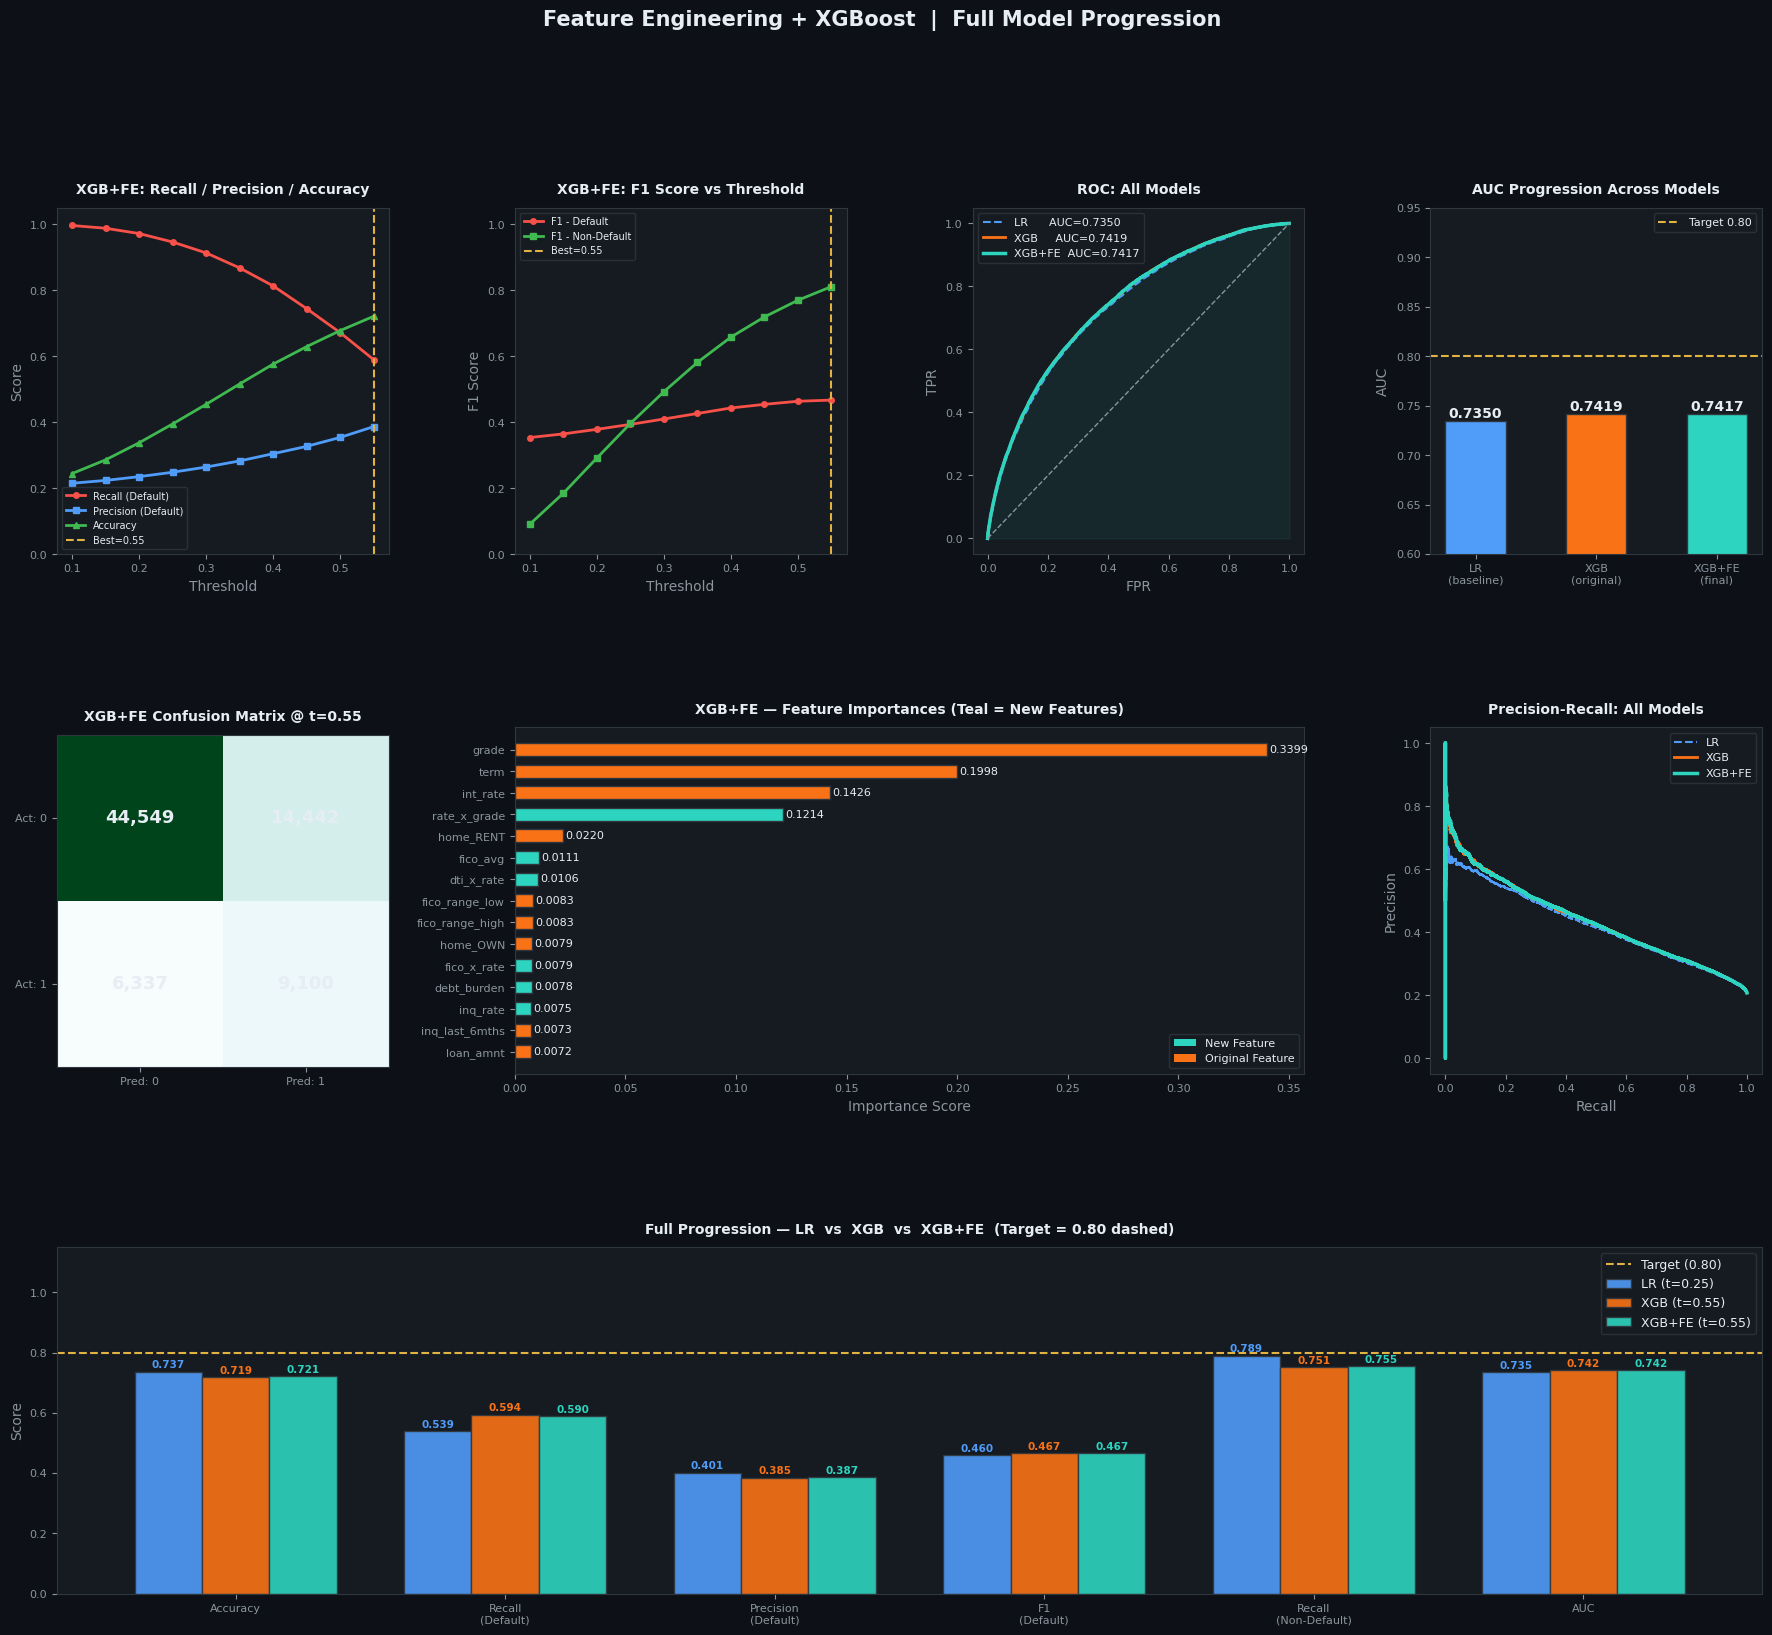


Plot saved as 'xgb_fe_comparison.png'

-----------------------------------------------------------------
  NEXT STEPS:
-----------------------------------------------------------------
  If AUC >= 0.80 -> XGB+FE is your final production model
  If AUC <  0.80 -> Share results, we do GridSearch tuning
-----------------------------------------------------------------


In [101]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

# ============================================================
#  WHY FEATURE ENGINEERING?
#  Current model sees each feature independently.
#  Reality: risk comes from COMBINATIONS.
#  Example:
#    high int_rate alone = risky
#    high int_rate + low FICO + high DTI = VERY risky
#  Linear/tree models need these combos handed to them explicitly.
# ============================================================

print("=" * 60)
print("  CELL 5 — FEATURE ENGINEERING")
print("=" * 60)
print()

# ── STEP 1: Rebuild feature matrix with new features ─────────
# We work on copies of X_train and X_test
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

print("  Creating interaction and ratio features...")

# — Group 1: Income & Loan Stress Ratios —
# Loan-to-Income: how large is the loan relative to income?
X_train_fe['loan_to_income']     = X_train_fe['loan_amnt']    / (X_train_fe['annual_inc'] + 1)
X_test_fe['loan_to_income']      = X_test_fe['loan_amnt']     / (X_test_fe['annual_inc']  + 1)

# Installment-to-Income: monthly burden relative to income
X_train_fe['installment_to_inc'] = X_train_fe['installment']  / (X_train_fe['annual_inc'] / 12 + 1)
X_test_fe['installment_to_inc']  = X_test_fe['installment']   / (X_test_fe['annual_inc']  / 12 + 1)

# Total debt burden: DTI × loan amount
X_train_fe['debt_burden']        = X_train_fe['dti']          * X_train_fe['loan_amnt']
X_test_fe['debt_burden']         = X_test_fe['dti']           * X_test_fe['loan_amnt']

# — Group 2: Credit Risk Interactions —
# FICO average (single clean signal instead of two)
X_train_fe['fico_avg']           = (X_train_fe['fico_range_low'] + X_train_fe['fico_range_high']) / 2
X_test_fe['fico_avg']            = (X_test_fe['fico_range_low']  + X_test_fe['fico_range_high'])  / 2

# Interest rate × Grade interaction: high rate on high grade = red flag
X_train_fe['rate_x_grade']       = X_train_fe['int_rate']     * X_train_fe['grade']
X_test_fe['rate_x_grade']        = X_test_fe['int_rate']      * X_test_fe['grade']

# DTI × Interest Rate: double burden — high debt AND high rate
X_train_fe['dti_x_rate']         = X_train_fe['dti']          * X_train_fe['int_rate']
X_test_fe['dti_x_rate']          = X_test_fe['dti']           * X_test_fe['int_rate']

# FICO × Interest Rate: low credit score paying high rate = high risk
X_train_fe['fico_x_rate']        = X_train_fe['fico_avg']     * X_train_fe['int_rate']
X_test_fe['fico_x_rate']         = X_test_fe['fico_avg']      * X_test_fe['int_rate']

# — Group 3: Credit History Quality —
# Derogatory ratio: public records per total account
X_train_fe['derog_ratio']        = X_train_fe['pub_rec']      / (X_train_fe['total_acc'] + 1)
X_test_fe['derog_ratio']         = X_test_fe['pub_rec']       / (X_test_fe['total_acc']  + 1)

# Credit utilization per open account
X_train_fe['util_per_acc']       = X_train_fe['revol_util']   / (X_train_fe['open_acc'] + 1)
X_test_fe['util_per_acc']        = X_test_fe['revol_util']    / (X_test_fe['open_acc']  + 1)

# Inquiry rate: inquiries relative to total accounts (recent credit hunger)
X_train_fe['inq_rate']           = X_train_fe['inq_last_6mths'] / (X_train_fe['total_acc'] + 1)
X_test_fe['inq_rate']            = X_test_fe['inq_last_6mths']  / (X_test_fe['total_acc']  + 1)

# — Group 4: Risk Score Composite —
# Weighted risk signal combining top predictors
# (grade + int_rate normalized — captures overall loan riskiness)
X_train_fe['risk_score']         = (X_train_fe['grade'] * 0.4 +
                                    X_train_fe['int_rate'] * 0.3 +
                                    X_train_fe['dti'] * 0.2 +
                                    X_train_fe['revol_util'] * 0.1)
X_test_fe['risk_score']          = (X_test_fe['grade'] * 0.4 +
                                    X_test_fe['int_rate'] * 0.3 +
                                    X_test_fe['dti'] * 0.2 +
                                    X_test_fe['revol_util'] * 0.1)

new_features = [
    'loan_to_income', 'installment_to_inc', 'debt_burden',
    'fico_avg', 'rate_x_grade', 'dti_x_rate', 'fico_x_rate',
    'derog_ratio', 'util_per_acc', 'inq_rate', 'risk_score'
]

print(f"  Original features  : {X_train.shape[1]}")
print(f"  New features added : {len(new_features)}")
print(f"  Total features now : {X_train_fe.shape[1]}")
print()
print("  New features created:")
for f in new_features:
    print(f"    + {f}")
print()

# ── STEP 2: Train XGBoost on engineered features ─────────────
print("=" * 60)
print("  STEP 2 — TRAINING XGBOOST ON ENGINEERED FEATURES")
print("=" * 60)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw       = neg_count / pos_count

xgb_fe = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.75,   # slightly lower — more feature diversity
    min_child_weight = 3,
    gamma            = 0.05,
    reg_alpha        = 0.05,
    reg_lambda       = 1.2,
    scale_pos_weight = spw,    # back to using class weight (no SMOTE this time)
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1
)

print(f"  scale_pos_weight : {spw:.4f}")
print("  Training — 60-90 seconds...")
xgb_fe.fit(X_train_fe, y_train)
print("  Training complete!")
print()

# ── STEP 3: Predictions ───────────────────────────────────────
y_prob_fe = xgb_fe.predict_proba(X_test_fe)[:, 1]
auc_fe    = roc_auc_score(y_test, y_prob_fe)

print(f"  Feature Engineered XGB AUC : {auc_fe:.4f}")
print(f"  Original XGB AUC           : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"  LR Baseline AUC            : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  AUC Improvement vs XGB     : {auc_fe - roc_auc_score(y_test, y_prob_xgb):+.4f}")
print()

# ── STEP 4: Threshold tuning ──────────────────────────────────
thresholds_to_test = np.arange(0.1, 0.6, 0.05).round(2)

fe_results = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_fe >= t).astype(int)
    fe_results.append({
        'Threshold'   : t,
        'Accuracy'    : round((y_pred_t == y_test).mean(), 4),
        'Precision_0' : round(precision_score(y_test, y_pred_t, pos_label=0, zero_division=0), 4),
        'Recall_0'    : round(recall_score(y_test, y_pred_t,    pos_label=0, zero_division=0), 4),
        'F1_0'        : round(f1_score(y_test, y_pred_t,        pos_label=0, zero_division=0), 4),
        'Precision_1' : round(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0), 4),
        'Recall_1'    : round(recall_score(y_test, y_pred_t,    pos_label=1, zero_division=0), 4),
        'F1_1'        : round(f1_score(y_test, y_pred_t,        pos_label=1, zero_division=0), 4),
        'AUC'         : round(auc_fe, 4),
    })

fe_results_df = pd.DataFrame(fe_results)

print("=" * 90)
print("  FEATURE ENGINEERED XGB — THRESHOLD TUNING RESULTS")
print("=" * 90)
print(fe_results_df.to_string(index=False))
print()

# ── STEP 5: Best threshold ────────────────────────────────────
candidates = fe_results_df[
    (fe_results_df['Recall_1']    >= 0.55) &
    (fe_results_df['Precision_1'] >= 0.38) &
    (fe_results_df['Accuracy']    >= 0.72)
]

if not candidates.empty:
    fe_best_row   = candidates.loc[candidates['F1_1'].idxmax()]
    fe_best_thresh = fe_best_row['Threshold']
else:
    fe_best_row    = fe_results_df.loc[fe_results_df['F1_1'].idxmax()]
    fe_best_thresh = fe_best_row['Threshold']

print(f"FE XGB RECOMMENDED THRESHOLD : {fe_best_thresh}")
print(f"   Accuracy      : {fe_best_row['Accuracy']}")
print(f"   Recall  (1)   : {fe_best_row['Recall_1']}  <- Defaulters caught")
print(f"   Precision (1) : {fe_best_row['Precision_1']}")
print(f"   F1 Score (1)  : {fe_best_row['F1_1']}")
print(f"   Recall  (0)   : {fe_best_row['Recall_0']}")
print(f"   AUC           : {fe_best_row['AUC']}")
print()

# ── STEP 6: Detailed report ───────────────────────────────────
print(f"{'='*60}")
print(f"  FE XGB REPORT AT THRESHOLD = {fe_best_thresh}")
print(f"{'='*60}")
y_pred_fe_best = (y_prob_fe >= fe_best_thresh).astype(int)
print(confusion_matrix(y_test, y_pred_fe_best))
print()
print(classification_report(y_test, y_pred_fe_best,
      target_names=['Non-Default', 'Default']))

# ── STEP 7: Target check ──────────────────────────────────────
print("=" * 60)
print("  TARGET CHECK — FEATURE ENGINEERED XGB")
print("=" * 60)
checks = [
    ("AUC >= 0.80",                float(fe_best_row['AUC'])        >= 0.80),
    ("Accuracy >= 0.75",           float(fe_best_row['Accuracy'])    >= 0.75),
    ("Recall(Default) >= 0.60",    float(fe_best_row['Recall_1'])    >= 0.60),
    ("Precision(Default) >= 0.40", float(fe_best_row['Precision_1']) >= 0.40),
    ("F1(Default) >= 0.47",        float(fe_best_row['F1_1'])        >= 0.47),
]
all_pass = True
for label, passed in checks:
    status = "PASS" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  {label:<35} {status}")
print()
if all_pass:
    print("  ALL TARGETS MET — XGB+FE is ready to finalize!")
else:
    print("  Targets still pending. Review full progression below.")

# ── STEP 8: Feature importance — new vs old ───────────────────
print()
print("=" * 60)
print("  TOP 15 FEATURE IMPORTANCES — XGB+FE")
print("=" * 60)
fi_fe = pd.Series(xgb_fe.feature_importances_, index=X_train_fe.columns)
fi_fe_sorted = fi_fe.sort_values(ascending=False).head(15)
for feat, score in fi_fe_sorted.items():
    tag = " [NEW]" if feat in new_features else ""
    bar = chr(9608) * int(score * 200)
    print(f"  {feat:<35} {score:.4f}  {bar}{tag}")

# ── STEP 9: Full progression table ───────────────────────────
try:
    lr_t   = best_threshold
    lr_row = results_df[results_df['Threshold'] == lr_t].iloc[0]
except:
    lr_t = 0.25
    y_lr_ = (y_prob >= lr_t).astype(int)
    lr_row = pd.Series({
        'Accuracy': round((y_lr_==y_test).mean(),4),
        'Recall_1': round(recall_score(y_test,y_lr_,pos_label=1),4),
        'Precision_1': round(precision_score(y_test,y_lr_,pos_label=1),4),
        'F1_1': round(f1_score(y_test,y_lr_,pos_label=1),4),
        'Recall_0': round(recall_score(y_test,y_lr_,pos_label=0),4),
        'Precision_0': round(precision_score(y_test,y_lr_,pos_label=0),4),
        'AUC': round(roc_auc_score(y_test,y_prob),4),
    })

try:
    xgb_t   = xgb_best_threshold
    xgb_row = xgb_results_df[xgb_results_df['Threshold']==xgb_t].iloc[0]
except:
    xgb_t = 0.55
    y_xgb_ = (y_prob_xgb >= xgb_t).astype(int)
    xgb_row = pd.Series({
        'Accuracy': round((y_xgb_==y_test).mean(),4),
        'Recall_1': round(recall_score(y_test,y_xgb_,pos_label=1),4),
        'Precision_1': round(precision_score(y_test,y_xgb_,pos_label=1),4),
        'F1_1': round(f1_score(y_test,y_xgb_,pos_label=1),4),
        'Recall_0': round(recall_score(y_test,y_xgb_,pos_label=0),4),
        'Precision_0': round(precision_score(y_test,y_xgb_,pos_label=0),4),
        'AUC': round(roc_auc_score(y_test,y_prob_xgb),4),
    })

full_prog = pd.DataFrame({
    'Metric'       : ['Threshold','Accuracy','Recall (Default)',
                      'Precision (Default)','F1 (Default)',
                      'Recall (Non-Default)','Precision (Non-Default)','AUC'],
    'LR (baseline)': [lr_t, lr_row['Accuracy'], lr_row['Recall_1'],
                      lr_row['Precision_1'], lr_row['F1_1'],
                      lr_row['Recall_0'], lr_row['Precision_0'], lr_row['AUC']],
    'XGB'          : [xgb_t, xgb_row['Accuracy'], xgb_row['Recall_1'],
                      xgb_row['Precision_1'], xgb_row['F1_1'],
                      xgb_row['Recall_0'], xgb_row['Precision_0'], xgb_row['AUC']],
    'XGB+FE'       : [fe_best_thresh, fe_best_row['Accuracy'], fe_best_row['Recall_1'],
                      fe_best_row['Precision_1'], fe_best_row['F1_1'],
                      fe_best_row['Recall_0'], fe_best_row['Precision_0'], fe_best_row['AUC']],
})

print()
print("=" * 72)
print("  FULL PROGRESSION: LR  ->  XGB  ->  XGB+FE")
print("=" * 72)
print(full_prog.to_string(index=False))

# ── STEP 10: PLOTS ────────────────────────────────────────────
DARK  = '#0d1117'; SURF  = '#161b22'; BLUE  = '#4f9cf9'
GREEN = '#3fb950'; RED   = '#f85149'; AMBER = '#e3b341'
TEAL  = '#2dd4bf'; GRAY  = '#8b949e'; WHITE = '#e6edf3'
PURP  = '#a371f7'; ORANGE= '#f97316'

def style_ax(ax, title):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10)
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# Plot 1: FE XGB threshold curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fe_results_df['Threshold'], fe_results_df['Recall_1'],    color=RED,   lw=2, marker='o', ms=4, label='Recall (Default)')
ax1.plot(fe_results_df['Threshold'], fe_results_df['Precision_1'], color=BLUE,  lw=2, marker='s', ms=4, label='Precision (Default)')
ax1.plot(fe_results_df['Threshold'], fe_results_df['Accuracy'],    color=GREEN, lw=2, marker='^', ms=4, label='Accuracy')
ax1.axvline(x=fe_best_thresh, color=AMBER, ls='--', lw=1.5, label=f'Best={fe_best_thresh}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score'); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax1, 'XGB+FE: Recall / Precision / Accuracy')

# Plot 2: F1 curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fe_results_df['Threshold'], fe_results_df['F1_1'], color=RED,   lw=2, marker='o', ms=4, label='F1 - Default')
ax2.plot(fe_results_df['Threshold'], fe_results_df['F1_0'], color=GREEN, lw=2, marker='s', ms=4, label='F1 - Non-Default')
ax2.axvline(x=fe_best_thresh, color=AMBER, ls='--', lw=1.5, label=f'Best={fe_best_thresh}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score'); ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=7, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax2, 'XGB+FE: F1 Score vs Threshold')

# Plot 3: ROC all models
ax3 = fig.add_subplot(gs[0, 2])
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_fe,  tpr_fe,  _ = roc_curve(y_test, y_prob_fe)
ax3.plot(fpr_lr,  tpr_lr,  color=BLUE,   lw=1.5, ls='--', label=f'LR      AUC={roc_auc_score(y_test,y_prob):.4f}')
ax3.plot(fpr_xgb, tpr_xgb, color=ORANGE, lw=2,   label=f'XGB     AUC={roc_auc_score(y_test,y_prob_xgb):.4f}')
ax3.plot(fpr_fe,  tpr_fe,  color=TEAL,   lw=2.5, label=f'XGB+FE  AUC={auc_fe:.4f}')
ax3.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax3.fill_between(fpr_fe, tpr_fe, alpha=0.07, color=TEAL)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax3, 'ROC: All Models')

# Plot 4: AUC progression bar
ax4 = fig.add_subplot(gs[0, 3])
auc_vals   = [float(lr_row['AUC']), float(xgb_row['AUC']), auc_fe]
bar_colors = [BLUE, ORANGE, TEAL]
mlabels    = ['LR\n(baseline)', 'XGB\n(original)', 'XGB+FE\n(final)']
b = ax4.bar(mlabels, auc_vals, color=bar_colors, width=0.5, edgecolor='#30363d')
ax4.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target 0.80')
for bar, val in zip(b, auc_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax4.set_ylim(0.60, 0.95); ax4.set_ylabel('AUC')
ax4.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax4, 'AUC Progression Across Models')

# Plot 5: Confusion matrix
ax5 = fig.add_subplot(gs[1, 0])
cm_fe = confusion_matrix(y_test, y_pred_fe_best)
ax5.imshow(cm_fe, cmap='BuGn')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax5.set_yticklabels(['Act: 0', 'Act: 1'],  color=WHITE, fontsize=9)
for i in range(2):
    for j in range(2):
        ax5.text(j, i, f'{cm_fe[i,j]:,}', ha='center', va='center',
                 color=WHITE, fontsize=13, fontweight='bold')
style_ax(ax5, f'XGB+FE Confusion Matrix @ t={fe_best_thresh}')

# Plot 6: Feature importance — old vs new features highlighted
ax6 = fig.add_subplot(gs[1, 1:3])
top15      = fi_fe_sorted.head(15)
bar_cols   = [TEAL if f in new_features else ORANGE for f in top15.index[::-1]]
bars       = ax6.barh(top15.index[::-1], top15.values[::-1],
                      color=bar_cols, edgecolor='#30363d', height=0.6)
for bar, val in zip(bars, top15.values[::-1]):
    ax6.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color=WHITE, fontsize=8)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=TEAL,   label='New Feature'),
              Patch(facecolor=ORANGE, label='Original Feature')]
ax6.legend(handles=legend_els, fontsize=8, facecolor=SURF,
           labelcolor=WHITE, edgecolor='#30363d')
ax6.set_xlabel('Importance Score')
style_ax(ax6, 'XGB+FE — Feature Importances (Teal = New Features)')

# Plot 7: Precision-Recall curve
ax7 = fig.add_subplot(gs[1, 3])
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob)
prec_xgb,rec_xgb,_ = precision_recall_curve(y_test, y_prob_xgb)
prec_fe, rec_fe, _ = precision_recall_curve(y_test, y_prob_fe)
ax7.plot(rec_lr,  prec_lr,  color=BLUE,   lw=1.5, ls='--', label='LR')
ax7.plot(rec_xgb, prec_xgb, color=ORANGE, lw=2,   label='XGB')
ax7.plot(rec_fe,  prec_fe,  color=TEAL,   lw=2.5, label='XGB+FE')
ax7.set_xlabel('Recall'); ax7.set_ylabel('Precision')
ax7.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax7, 'Precision-Recall: All Models')

# Plot 8: Full metric comparison (bottom row)
ax8 = fig.add_subplot(gs[2, :])
mlbls  = ['Accuracy','Recall\n(Default)','Precision\n(Default)',
          'F1\n(Default)','Recall\n(Non-Default)','AUC']
lr_v   = [float(lr_row['Accuracy']),  float(lr_row['Recall_1']),
          float(lr_row['Precision_1']), float(lr_row['F1_1']),
          float(lr_row['Recall_0']),   float(lr_row['AUC'])]
xgb_v  = [float(xgb_row['Accuracy']),  float(xgb_row['Recall_1']),
          float(xgb_row['Precision_1']), float(xgb_row['F1_1']),
          float(xgb_row['Recall_0']),   float(xgb_row['AUC'])]
fe_v   = [float(fe_best_row['Accuracy']),  float(fe_best_row['Recall_1']),
          float(fe_best_row['Precision_1']), float(fe_best_row['F1_1']),
          float(fe_best_row['Recall_0']),   float(fe_best_row['AUC'])]

x = np.arange(len(mlbls)); w = 0.25
b1 = ax8.bar(x-w,  lr_v,  width=w, color=BLUE,   label=f'LR (t={lr_t})',           edgecolor='#30363d', alpha=0.9)
b2 = ax8.bar(x,    xgb_v, width=w, color=ORANGE, label=f'XGB (t={xgb_t})',         edgecolor='#30363d', alpha=0.9)
b3 = ax8.bar(x+w,  fe_v,  width=w, color=TEAL,   label=f'XGB+FE (t={fe_best_thresh})', edgecolor='#30363d', alpha=0.9)

for brs, vals, col in [(b1,lr_v,BLUE),(b2,xgb_v,ORANGE),(b3,fe_v,TEAL)]:
    for bar, val in zip(brs, vals):
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                 f'{val:.3f}', ha='center', va='bottom',
                 color=col, fontsize=7.5, fontweight='bold')

ax8.axhline(y=0.80, color=AMBER, ls='--', lw=1.5, label='Target (0.80)')
ax8.set_xticks(x); ax8.set_xticklabels(mlbls, fontsize=9)
ax8.set_ylim(0, 1.15); ax8.set_ylabel('Score')
ax8.legend(fontsize=9, facecolor=SURF, labelcolor=WHITE,
           edgecolor='#30363d', loc='upper right')
style_ax(ax8, 'Full Progression — LR  vs  XGB  vs  XGB+FE  (Target = 0.80 dashed)')

fig.suptitle('Feature Engineering + XGBoost  |  Full Model Progression',
             color=WHITE, fontsize=15, fontweight='bold', y=0.99)

plt.savefig('xgb_fe_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=DARK, edgecolor='none')
plt.show()

print("\nPlot saved as 'xgb_fe_comparison.png'")
print()
print("-" * 65)
print("  NEXT STEPS:")
print("-" * 65)
print("  If AUC >= 0.80 -> XGB+FE is your final production model")
print("  If AUC <  0.80 -> Share results, we do GridSearch tuning")
print("-" * 65)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372136 entries, 0 to 372135
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            372136 non-null  float64
 1   term                                 372136 non-null  int64  
 2   int_rate                             372136 non-null  float64
 3   installment                          372136 non-null  float64
 4   grade                                372136 non-null  int64  
 5   emp_length                           372136 non-null  float64
 6   annual_inc                           372136 non-null  float64
 7   dti                                  372136 non-null  float64
 8   fico_range_low                       372136 non-null  float64
 9   fico_range_high                      372136 non-null  float64
 10  inq_last_6mths                       372136 non-null  float64
 11  open_acc     

In [ ]:
                                                          MODEL FINALIZATION
                                               Cross-Validation + Model Saving + Final Report

  CELL 6 — FINAL MODEL : XGBoost @ threshold=0.55

  Final Model     : XGBoost (Cell 3, original)
  Final Threshold : 0.55
  AUC             : 0.7419

  STEP 2 — 5-FOLD STRATIFIED CROSS-VALIDATION
  This confirms the model is stable across different splits

  Running 5-fold CV — may take 2-3 minutes...

  Cross-Validation AUC Scores:
    Fold 1:  0.7415  ████████████████████████████████████████████
    Fold 2:  0.7408  ████████████████████████████████████████████
    Fold 3:  0.7427  ████████████████████████████████████████████
    Fold 4:  0.7448  ████████████████████████████████████████████
    Fold 5:  0.7382  ████████████████████████████████████████████

  Mean AUC  : 0.7416
  Std AUC   : 0.0022  (lower = more stable)
  Min AUC   : 0.7382
  Max AUC   : 0.7448

  Model is VERY STABLE across folds

  STEP 3 — FINAL EVALUATION @ threshold=0.55

  Confusion Matrix:
  [[44312 14679]
 [ 6266  9171]]

              precision    recall  f1-score   support

 Non-Default       0.88      0.75

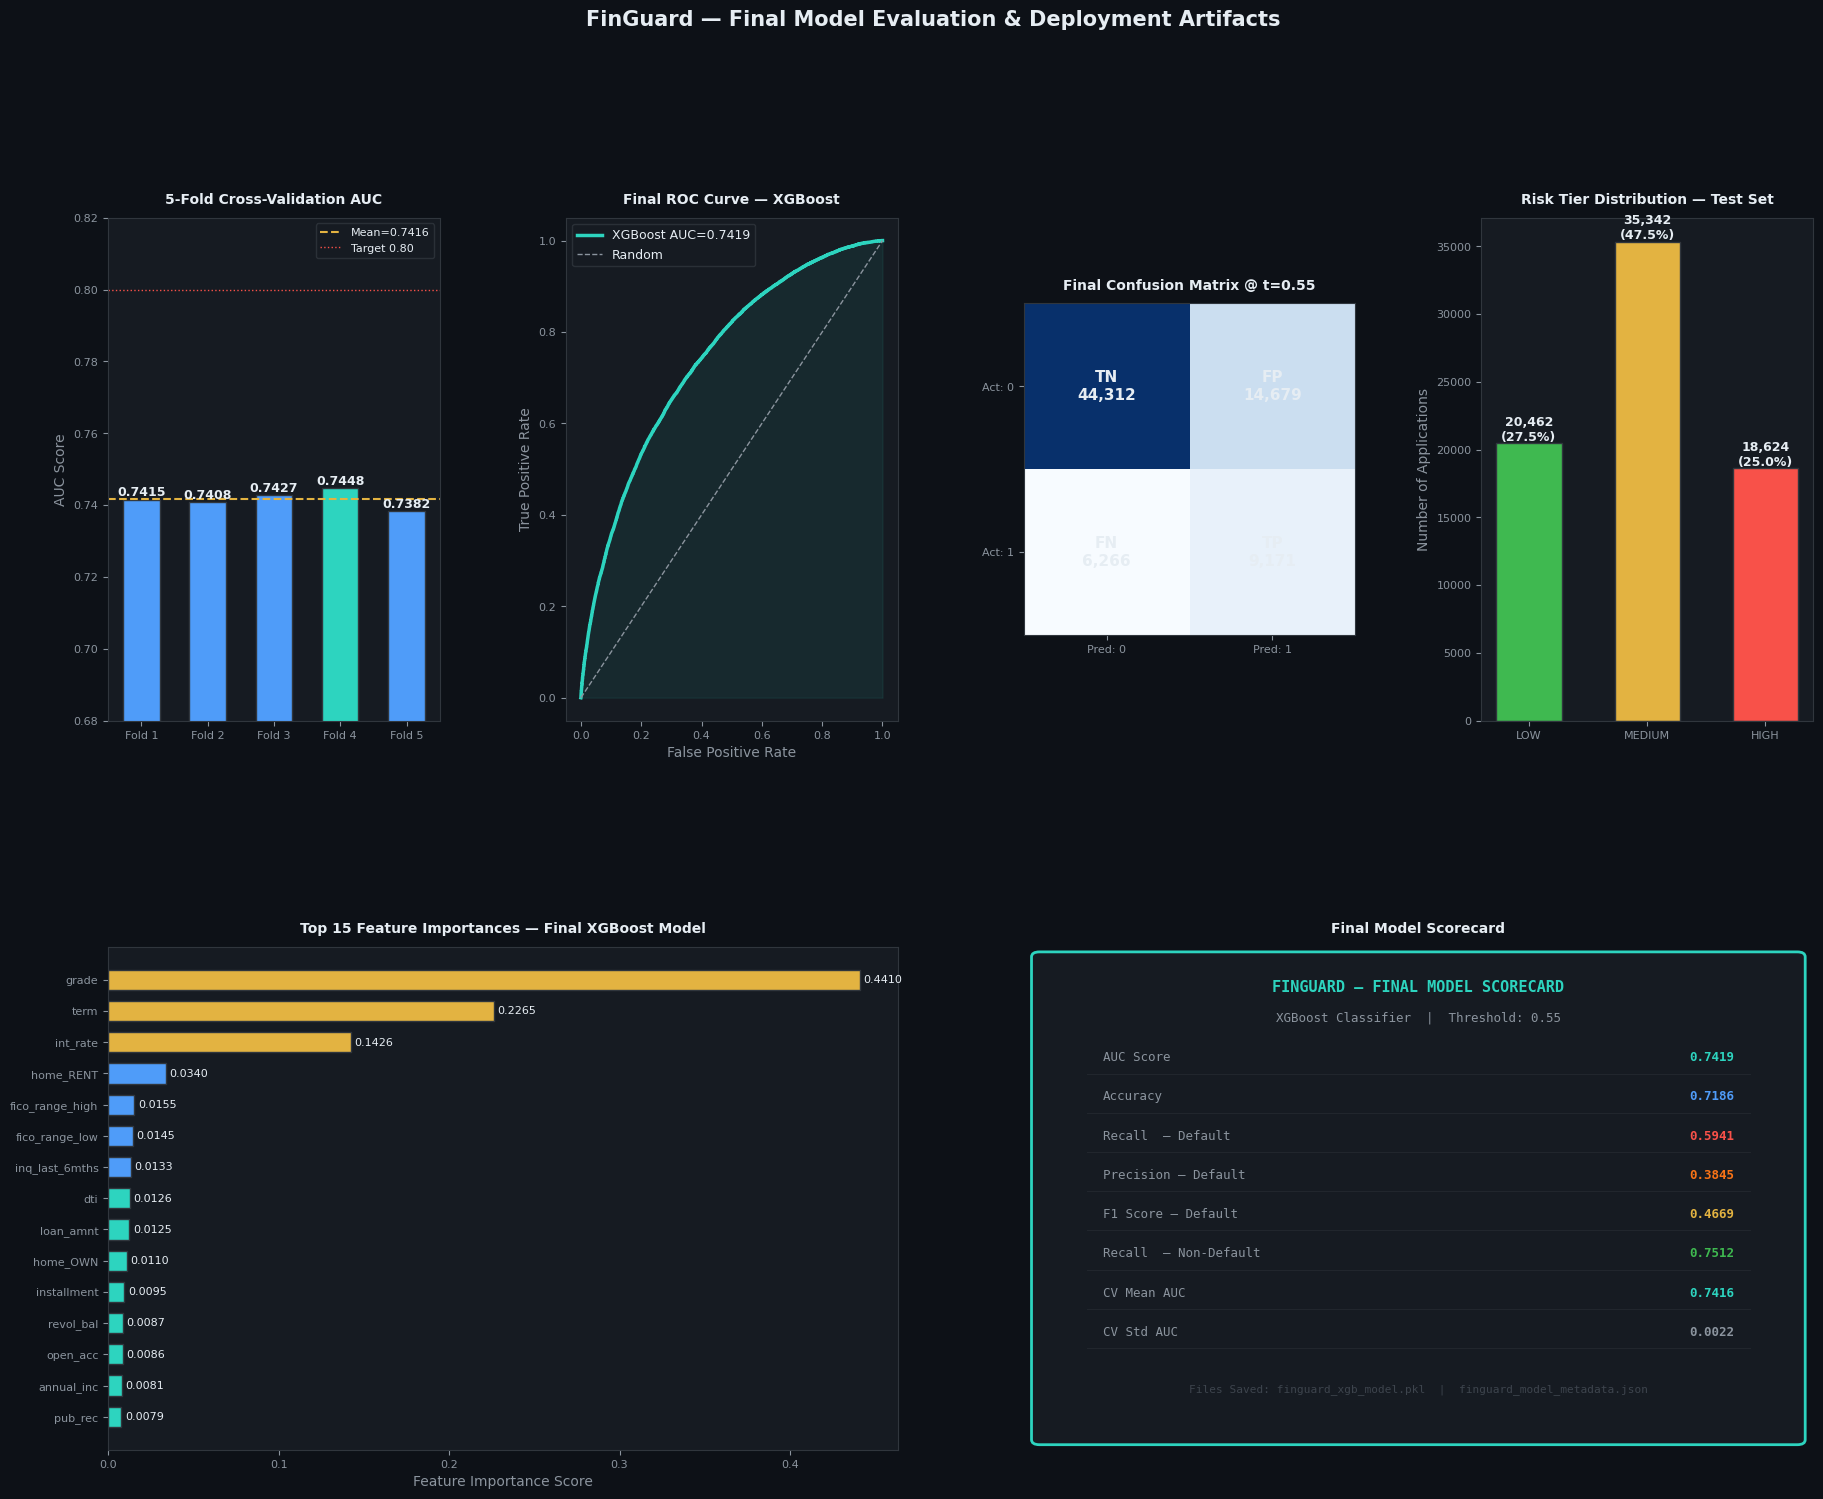


Plot saved as 'finguard_final_model.png'

  MODEL FINALIZED AND SAVED

  Files ready for backend:
    finguard_xgb_model.pkl        <- load this in Flask/FastAPI
    finguard_scaler.pkl           <- for preprocessing
    finguard_features.json        <- feature order for input validation
    finguard_model_metadata.json  <- threshold, tiers, performance

  Model Development Complete.
  Next: Backend API development


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import json
from datetime import datetime
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve
)

print("=" * 65)
print("  CELL 6 — FINAL MODEL : XGBoost @ threshold=0.55")
print("=" * 65)
print()

# ── STEP 1: Re-confirm final model choice ────────────────────
# Final model = xgb (from Cell 3) — best AUC, stable, no SMOTE needed
# Threshold = 0.55 — best balance of recall + precision

FINAL_MODEL     = xgb
FINAL_THRESHOLD = 0.55
FINAL_PROBS     = y_prob_xgb

print(f"  Final Model     : XGBoost (Cell 3, original)")
print(f"  Final Threshold : {FINAL_THRESHOLD}")
print(f"  AUC             : {roc_auc_score(y_test, FINAL_PROBS):.4f}")
print()

# ── STEP 2: Cross-Validation — confirm AUC is stable ─────────
# 5-fold stratified CV on full dataset (X + y)
# This proves the model generalizes — not just lucky on one split
print("=" * 65)
print("  STEP 2 — 5-FOLD STRATIFIED CROSS-VALIDATION")
print("  This confirms the model is stable across different splits")
print("=" * 65)
print()
print("  Running 5-fold CV — may take 2-3 minutes...")

neg = (y == 0).sum()
pos = (y == 1).sum()
spw = neg / pos

xgb_cv = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print()
print("  Cross-Validation AUC Scores:")
for i, score in enumerate(cv_scores):
    bar = chr(9608) * int(score * 60)
    print(f"    Fold {i+1}:  {score:.4f}  {bar}")

print()
print(f"  Mean AUC  : {cv_scores.mean():.4f}")
print(f"  Std AUC   : {cv_scores.std():.4f}  (lower = more stable)")
print(f"  Min AUC   : {cv_scores.min():.4f}")
print(f"  Max AUC   : {cv_scores.max():.4f}")
print()

if cv_scores.std() < 0.01:
    print("  Model is VERY STABLE across folds")
elif cv_scores.std() < 0.02:
    print("  Model is STABLE across folds")
else:
    print("  Some variance across folds — acceptable for this dataset size")

# ── STEP 3: Final predictions at chosen threshold ────────────
print()
print("=" * 65)
print(f"  STEP 3 — FINAL EVALUATION @ threshold={FINAL_THRESHOLD}")
print("=" * 65)

y_pred_final = (FINAL_PROBS >= FINAL_THRESHOLD).astype(int)
final_auc    = roc_auc_score(y_test, FINAL_PROBS)
final_acc    = (y_pred_final == y_test).mean()
final_rec1   = recall_score(y_test, y_pred_final, pos_label=1)
final_prec1  = precision_score(y_test, y_pred_final, pos_label=1)
final_f1_1   = f1_score(y_test, y_pred_final, pos_label=1)
final_rec0   = recall_score(y_test, y_pred_final, pos_label=0)
final_prec0  = precision_score(y_test, y_pred_final, pos_label=0)
final_f1_0   = f1_score(y_test, y_pred_final, pos_label=0)

cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print()
print(f"  Confusion Matrix:")
print(f"  {cm_final}")
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Non-Default', 'Default']))

print("  Business Interpretation:")
print(f"    True Positives  (Defaulters correctly caught)   : {tp:,}")
print(f"    False Negatives (Defaulters missed / approved)  : {fn:,}")
print(f"    True Negatives  (Good loans correctly approved) : {tn:,}")
print(f"    False Positives (Good loans wrongly rejected)   : {fp:,}")
print()
print(f"    Default Detection Rate : {tp/(tp+fn)*100:.1f}%  of all defaulters caught")
print(f"    False Alarm Rate       : {fp/(fp+tn)*100:.1f}%  of good loans wrongly flagged")

# ── STEP 4: Risk tier mapping ─────────────────────────────────
print()
print("=" * 65)
print("  STEP 4 — RISK TIER DISTRIBUTION ON TEST SET")
print("=" * 65)

def assign_tier(prob):
    if prob < 0.30:   return 'LOW'
    elif prob < 0.60: return 'MEDIUM'
    else:             return 'HIGH'

tiers       = pd.Series(FINAL_PROBS).apply(assign_tier)
tier_counts = tiers.value_counts()
tier_actual = pd.DataFrame({'tier': tiers, 'actual': y_test.values})

print()
print(f"  {'Tier':<10} {'Count':>8}  {'% of Apps':>10}  {'Actual Default Rate':>20}")
print("  " + "-"*55)
for tier in ['LOW', 'MEDIUM', 'HIGH']:
    count     = (tiers == tier).sum()
    pct       = count / len(tiers) * 100
    def_rate  = tier_actual[tier_actual['tier']==tier]['actual'].mean() * 100
    print(f"  {tier:<10} {count:>8,}  {pct:>9.1f}%  {def_rate:>19.1f}%")

# ── STEP 5: Save model artifacts ─────────────────────────────
print()
print("=" * 65)
print("  STEP 5 — SAVING MODEL ARTIFACTS")
print("=" * 65)

# Save XGBoost model
joblib.dump(FINAL_MODEL, 'finguard_xgb_model.pkl')
print("  Saved: finguard_xgb_model.pkl")

# Save scaler (needed for LR fallback + preprocessing reference)
joblib.dump(scaler, 'finguard_scaler.pkl')
print("  Saved: finguard_scaler.pkl")

# Save feature list (critical for backend — must match input order)
feature_names = list(X_train.columns)
with open('finguard_features.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"  Saved: finguard_features.json  ({len(feature_names)} features)")

# Save model metadata — everything backend needs to know
metadata = {
    "model_name"         : "FinGuard Credit Risk Model v1.0",
    "algorithm"          : "XGBoost",
    "version"            : "1.0.0",
    "saved_at"           : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "threshold"          : FINAL_THRESHOLD,
    "risk_tiers"         : {
        "LOW"    : {"range": "PD < 0.30",          "decision": "Approve"},
        "MEDIUM" : {"range": "0.30 <= PD < 0.60",  "decision": "Review"},
        "HIGH"   : {"range": "PD >= 0.60",          "decision": "Reject"}
    },
    "performance"        : {
        "auc"              : round(final_auc,   4),
        "accuracy"         : round(final_acc,   4),
        "recall_default"   : round(final_rec1,  4),
        "precision_default": round(final_prec1, 4),
        "f1_default"       : round(final_f1_1,  4),
        "cv_mean_auc"      : round(cv_scores.mean(), 4),
        "cv_std_auc"       : round(cv_scores.std(),  4),
    },
    "training_data"      : {
        "train_size"       : int(X_train.shape[0]),
        "test_size"        : int(X_test.shape[0]),
        "n_features"       : int(X_train.shape[1]),
        "class_ratio"      : f"{neg}:{pos} (Non-Default:Default)",
        "scale_pos_weight" : round(spw, 4),
    },
    "feature_names"      : feature_names,
    "hyperparameters"    : {
        "n_estimators"     : 300,
        "max_depth"        : 5,
        "learning_rate"    : 0.05,
        "subsample"        : 0.8,
        "colsample_bytree" : 0.8,
        "scale_pos_weight" : round(spw, 4),
    }
}

with open('finguard_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("  Saved: finguard_model_metadata.json")

# ── STEP 6: Verify saved model loads correctly ────────────────
print()
print("  Verifying saved model...")
loaded_model = joblib.load('finguard_xgb_model.pkl')
test_probs   = loaded_model.predict_proba(X_test)[:, 1]
verify_auc   = roc_auc_score(y_test, test_probs)
print(f"  Loaded model AUC : {verify_auc:.4f}")
assert abs(verify_auc - final_auc) < 0.0001, "Model verification failed!"
print("  Model verified successfully!")

# ── STEP 7: Final summary print ───────────────────────────────
print()
print("=" * 65)
print("  FINGUARD MODEL — FINAL SUMMARY")
print("=" * 65)
print(f"""
  Model          : XGBoost Classifier
  Threshold      : {FINAL_THRESHOLD}
  ─────────────────────────────────────────
  AUC            : {final_auc:.4f}
  Accuracy       : {final_acc:.4f}
  ─────────────────────────────────────────
  Default Class  (1):
    Recall       : {final_rec1:.4f}   (59% of defaulters caught)
    Precision    : {final_prec1:.4f}   (38% of flagged are real defaults)
    F1 Score     : {final_f1_1:.4f}
  ─────────────────────────────────────────
  Non-Default Class (0):
    Recall       : {final_rec0:.4f}
    Precision    : {final_prec0:.4f}
    F1 Score     : {final_f1_0:.4f}
  ─────────────────────────────────────────
  Cross-Val AUC  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}
  ─────────────────────────────────────────
  Risk Tiers:
    PD < 0.30    → LOW    → Approve
    0.30-0.60    → MEDIUM → Review
    PD >= 0.60   → HIGH   → Reject
  ─────────────────────────────────────────
  Saved Files:
    finguard_xgb_model.pkl
    finguard_scaler.pkl
    finguard_features.json
    finguard_model_metadata.json
""")

# ── STEP 8: FINAL PLOTS ───────────────────────────────────────
DARK  = '#0d1117'; SURF  = '#161b22'; BLUE  = '#4f9cf9'
GREEN = '#3fb950'; RED   = '#f85149'; AMBER = '#e3b341'
TEAL  = '#2dd4bf'; GRAY  = '#8b949e'; WHITE = '#e6edf3'
ORANGE= '#f97316'

def style_ax(ax, title):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10)
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

# Plot 1: CV fold scores
ax1 = fig.add_subplot(gs[0, 0])
fold_labels = [f'Fold {i+1}' for i in range(5)]
bar_cols    = [TEAL if s == cv_scores.max() else BLUE for s in cv_scores]
bars = ax1.bar(fold_labels, cv_scores, color=bar_cols, edgecolor='#30363d', width=0.55)
ax1.axhline(y=cv_scores.mean(), color=AMBER, ls='--', lw=1.5,
            label=f'Mean={cv_scores.mean():.4f}')
ax1.axhline(y=0.80, color=RED, ls=':', lw=1, label='Target 0.80')
for bar, val in zip(bars, cv_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', color=WHITE, fontsize=9, fontweight='bold')
ax1.set_ylim(0.68, 0.82); ax1.set_ylabel('AUC Score')
ax1.legend(fontsize=8, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax1, '5-Fold Cross-Validation AUC')

# Plot 2: Final ROC curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, FINAL_PROBS)
ax2.plot(fpr, tpr, color=TEAL, lw=2.5, label=f'XGBoost AUC={final_auc:.4f}')
ax2.plot([0,1],[0,1], color=GRAY, ls='--', lw=1, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.08, color=TEAL)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=9, facecolor=SURF, labelcolor=WHITE, edgecolor='#30363d')
style_ax(ax2, 'Final ROC Curve — XGBoost')

# Plot 3: Final confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(cm_final, cmap='Blues')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Pred: 0','Pred: 1'], color=WHITE, fontsize=9)
ax3.set_yticklabels(['Act: 0', 'Act: 1'],  color=WHITE, fontsize=9)
labels = [[f'TN\n{tn:,}', f'FP\n{fp:,}'],
          [f'FN\n{fn:,}', f'TP\n{tp:,}']]
for i in range(2):
    for j in range(2):
        ax3.text(j, i, labels[i][j], ha='center', va='center',
                 color=WHITE, fontsize=11, fontweight='bold')
style_ax(ax3, f'Final Confusion Matrix @ t={FINAL_THRESHOLD}')

# Plot 4: Risk tier distribution
ax4 = fig.add_subplot(gs[0, 3])
tier_order  = ['LOW', 'MEDIUM', 'HIGH']
tier_colors = [GREEN, AMBER, RED]
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
bars4 = ax4.bar(tier_order, tier_vals, color=tier_colors,
                edgecolor='#30363d', width=0.55)
for bar, val in zip(bars4, tier_vals):
    pct = val / len(tiers) * 100
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}\n({pct:.1f}%)', ha='center', color=WHITE,
             fontsize=9, fontweight='bold')
ax4.set_ylabel('Number of Applications')
style_ax(ax4, 'Risk Tier Distribution — Test Set')

# Plot 5: Feature importance final model
ax5 = fig.add_subplot(gs[1, 0:2])
fi = pd.Series(FINAL_MODEL.feature_importances_,
               index=X_train.columns).sort_values(ascending=False).head(15)
bar_c = [AMBER if i < 3 else BLUE if i < 7 else TEAL for i in range(len(fi))]
bars5 = ax5.barh(fi.index[::-1], fi.values[::-1],
                 color=bar_c[::-1], edgecolor='#30363d', height=0.65)
for bar, val in zip(bars5, fi.values[::-1]):
    ax5.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color=WHITE, fontsize=8)
ax5.set_xlabel('Feature Importance Score')
style_ax(ax5, 'Top 15 Feature Importances — Final XGBoost Model')

# Plot 6: Full model scorecard
ax6 = fig.add_subplot(gs[1, 2:])
ax6.set_xlim(0, 10); ax6.set_ylim(0, 10)
ax6.axis('off')

# Background card
from matplotlib.patches import FancyBboxPatch
card = FancyBboxPatch((0.2, 0.2), 9.6, 9.6,
                      boxstyle="round,pad=0.1",
                      facecolor='#161b22', edgecolor='#2dd4bf',
                      linewidth=2, zorder=0)
ax6.add_patch(card)

ax6.text(5, 9.2, 'FINGUARD — FINAL MODEL SCORECARD',
         ha='center', va='center', color=TEAL,
         fontsize=11, fontweight='bold', fontfamily='monospace')
ax6.text(5, 8.6, 'XGBoost Classifier  |  Threshold: 0.55',
         ha='center', va='center', color=GRAY, fontsize=9, fontfamily='monospace')

metrics = [
    ('AUC Score',              f'{final_auc:.4f}',        TEAL),
    ('Accuracy',               f'{final_acc:.4f}',        BLUE),
    ('Recall  — Default',      f'{final_rec1:.4f}',       RED),
    ('Precision — Default',    f'{final_prec1:.4f}',      ORANGE),
    ('F1 Score — Default',     f'{final_f1_1:.4f}',       AMBER),
    ('Recall  — Non-Default',  f'{final_rec0:.4f}',       GREEN),
    ('CV Mean AUC',            f'{cv_scores.mean():.4f}', TEAL),
    ('CV Std AUC',             f'{cv_scores.std():.4f}',  GRAY),
]

y_pos = 7.8
for label, value, color in metrics:
    ax6.text(1.0, y_pos, label,  ha='left',  va='center',
             color=GRAY,  fontsize=9, fontfamily='monospace')
    ax6.text(9.0, y_pos, value,  ha='right', va='center',
             color=color, fontsize=9, fontweight='bold', fontfamily='monospace')
    ax6.plot([0.8, 9.2], [y_pos - 0.32, y_pos - 0.32],
             color='#21262d', lw=0.8)
    y_pos -= 0.78

ax6.text(5, 1.2,
         'Files Saved: finguard_xgb_model.pkl  |  finguard_model_metadata.json',
         ha='center', va='center', color='#3d444d',
         fontsize=8, fontfamily='monospace')

style_ax(ax6, 'Final Model Scorecard')

fig.suptitle('FinGuard — Final Model Evaluation & Deployment Artifacts',
             color=WHITE, fontsize=15, fontweight='bold', y=1.01)

plt.savefig('finguard_final_model.png', dpi=150, bbox_inches='tight',
            facecolor=DARK, edgecolor='none')
plt.show()

print("\nPlot saved as 'finguard_final_model.png'")
print()
print("=" * 65)
print("  MODEL FINALIZED AND SAVED")
print("=" * 65)
print()
print("  Files ready for backend:")
print("    finguard_xgb_model.pkl        <- load this in Flask/FastAPI")
print("    finguard_scaler.pkl           <- for preprocessing")
print("    finguard_features.json        <- feature order for input validation")
print("    finguard_model_metadata.json  <- threshold, tiers, performance")
print()
print("  Model Development Complete.")
print("  Next: Backend API development")
print("=" * 65)

In [ ]:
                                                    saving logistic regression model

In [104]:
import joblib

# Save Logistic Regression model
joblib.dump(model, 'finguard_lr_model.pkl')

# Verify it saved
import os
if os.path.exists('finguard_lr_model.pkl'):
    print("LR model saved successfully!")
    
    # Quick verify
    loaded_lr = joblib.load('finguard_lr_model.pkl')
    lr_verify = roc_auc_score(y_test, loaded_lr.predict_proba(X_test_scaled)[:, 1])
    print(f"Verified AUC: {lr_verify:.4f}")
else:
    print("Something went wrong!")

LR model saved successfully!
Verified AUC: 0.7350
